## 端到端机器学习项目
---

* 端到端机器学习项目的主要步骤：
    1. 框定问题
        1. 任务目标是什么
        2. 当前的解决方案是什么样的（如果有）
        3. 设计你的系统
    2. 选择性能指标
        * RMSE-均方根误差
        * MAE-平均绝对误差
    3. 检查假设
        * 检查框定问题时所提出的所有假设，可尽早发现问题
    4. 获取数据
    5. 快速浏览数据结构
    6. 创建测试集
    7. 探索和可视化数据以获得见解
    8. 为机器学习算法准备数据
    9. 选择和训练模型
---

In [1]:
# 获取和加载数据的函数
from pathlib import Path # 用面向对象的方式处理路径（跨 Windows/Linux/macOS 更稳），例如拼路径、判断文件是否存在、创建目录等。
import pandas as pd # 读取 CSV 并返回 DataFrame。
import tarfile # 用于打开和解压 .tgz（本质是 tar + gzip）压缩包。
import urllib.request # 标准库的下载工具，用于把 URL 指向的文件下载到本地。

from sympy.abc import alpha


# 定义一个无参数函数，默认把数据放到当前工作目录下的 datasets/ 中。
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz") # 1. 定义压缩包路径
    # 2. 判断本地是否已存在压缩包；不存在就下载
    if not tarball_path.is_file():
        # 创建目录：
        Path("datasets").mkdir(parents=True, exist_ok=True) # parents=True：如果中间目录不存在（例如 datasets/），自动递归创建；exist_ok=True：如果目录已经存在，不报错。
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path) # 下载：从 url 下载文件到本地 tarball_path。
        # 3. 打开压缩包并解压到 datasets 目录
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets") # extractall(path="datasets")：把压缩包里所有内容解压到 datasets/ 目录下。
    return pd.read_csv("datasets/housing/housing.csv")

housing = load_housing_data()

# 5.快速浏览数据结构
1. `DataFrame.head()` # 查看数据的前五行
2. `DataFrame.info()` # 快速描述 DataFrame 的**结构信息**，包括行数、列数、列类型、非空数量、内存占用等。
3. `DataFrame['attribute'].value_counts` # 用于**统计某一列中各取值出现的频数，并按出现次数从高到低排序**返回结果。
4. `DataFrame.describe()` # 用于对 **数值型特征** 进行统计描述
5. `DataFrame.hist()` # 为每个数值属性绘制直方图

In [2]:
# .head() 查看数据的前五行
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# info() 快速描述 DataFrame 的结构信息，包括行数、列数、列类型、非空数量、内存占用等。
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


---

# 📊 1. `housing_data.info()` 简易笔记

## 1. `info()` 的作用

`DataFrame.info()` 用于**快速查看数据集的整体结构**，主要包括：

* 样本数量（行数）
* 特征数量（列数）
* 每一列的数据类型（dtype）
* 每一列的非空值数量
* 是否存在缺失值
* 数据集的内存占用情况

该方法常用于 **数据读取后的第一步检查（数据体检）**。

---

## 2. 数据集整体信息

```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
```

* 数据类型：`pandas.DataFrame`
* 样本数量：**20640 条**
* 索引范围：`0 ~ 20639`（默认整数索引）
* 特征数量：**10 个**

---

## 3. 各列字段信息

| 序号 | 字段名                | 非空数量  | 数据类型    | 说明          |
| -- | ------------------ | ----- | ------- | ----------- |
| 0  | longitude          | 20640 | float64 | 经度          |
| 1  | latitude           | 20640 | float64 | 纬度          |
| 2  | housing_median_age | 20640 | float64 | 房屋中位年龄      |
| 3  | total_rooms        | 20640 | float64 | 房间总数        |
| 4  | total_bedrooms     | 20433 | float64 | 卧室总数（存在缺失）  |
| 5  | population         | 20640 | float64 | 人口数量        |
| 6  | households         | 20640 | float64 | 家庭数量        |
| 7  | median_income      | 20640 | float64 | 收入中位数       |
| 8  | median_house_value | 20640 | float64 | 房价中位数（预测目标） |
| 9  | ocean_proximity    | 20640 | object  | 距离海洋的类别特征   |

---

## 4. 缺失值情况

* `total_bedrooms` 列存在缺失值
* 缺失数量：
  [
  20640 - 20433 = 207
  ]

> 该列在建模前需要进行 **缺失值处理（如中位数填补）**。

---

## 5. 数据类型分布

```text
dtypes: float64(9), object(1)
```

* 数值型特征：**9 列（float64）**
* 类别型特征：**1 列（object）**

其中：

* `ocean_proximity` 为类别特征，需在建模前进行编码（如 One-Hot Encoding）。

---

## 6. 内存占用情况

```text
memory usage: 1.6+ MB
```

* 数据集体量较小
* 适合进行探索性分析（EDA）和传统机器学习模型训练

---

## 7. 小结

* 该数据集为 **典型的回归问题数据**
* 存在 **少量缺失值**
* 同时包含 **数值特征与类别特征**
* 在建模前需要进行：

  * 缺失值处理
  * 类别特征编码
  * （可选）特征缩放

---



# 2. `value_counts()`
* 查看9   ocean_proximity     20640 non-null  object 的类型为python对象，由于是从csv文件中加载的，所以确定它为文本属性
* 使用value_counts()方法找出存在哪些类型以及每个类别有多少个地区
    * <1H OCEAN <1小时车程
    * 内陆
    * 靠近海洋
    * 靠近海湾
    * 岛屿

In [4]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

* describe()方法显示数字属性的摘要

---

# 📈 3. `housing.describe()` 简要说明

## 1. 方法作用

`DataFrame.describe()` 用于对 **数值型特征** 进行统计描述，主要包括：

* 非空样本数（count）
* 均值（mean）
* 标准差（std）
* 最小值 / 最大值（min / max）
* 四分位数（25%、50%、75%）

该方法常用于 **探索性数据分析（EDA）阶段**，帮助快速了解数据分布情况。

---

## 2. 样本与缺失值情况

* 数据集总样本数：**20640**
* 所有数值列中，仅：

  * `total_bedrooms` 存在缺失值（20433 条非空）
* 缺失样本数量：**207 条**

---

## 3. 特征分布特征

* 经纬度（`longitude`, `latitude`）显示数据位于 **美国加州区域**
* `housing_median_age` 最大值为 **52**，存在明显的取值上限
* `median_income` 均值约为 **3.87**（单位为标准化收入指标）
* `median_house_value` 均值约为 **20.7 万美元**

---

## 4. 房价特征的重要现象

* `median_house_value` 最大值为 **500001**
* 说明房价数据存在 **人为封顶（截断）现象**
* 高价区域真实房价未被完整反映，可能影响回归模型性能

---

## 5. 建模启示

* 需要对 `total_bedrooms` 进行缺失值处理
* 特征尺度差异较大，线性模型前应进行标准化
* 可通过构造比值特征（如人均房间数）提升模型效果

---

## 6. 小结

`housing.describe()` 揭示了该数据集存在 **缺失值、分布偏态及标签封顶** 等典型问题，为后续 **数据预处理与特征工程** 提供了重要依据。

---


In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# 4. 为每个数值属性绘制直方图 `.hist()`

---

## 2. 功能说明

* `housing.hist()`
  使用 **pandas 内置的直方图方法**，对 DataFrame 中所有 **数值型特征** 自动绘制直方图。
* 每一个数值特征对应一个子图，用于展示其取值分布情况。

---

## 3. 参数解释

* `bins=50`

  * 指定直方图的区间数量（柱子数量）
  * 区间数越多，分布细节越清晰

* `figsize=(12, 8)`

  * 设置整张图的大小（宽 12 英寸，高 8 英寸）
  * 避免子图过于拥挤，提升可读性

* `plt.show()`

  * 显式显示图像
  * 在脚本或 `.py` 文件中是必需的

---

## 4. 使用目的

* 观察各特征的分布形态（是否偏态、长尾分布）
* 发现异常值或数据截断现象
* 为后续特征工程（如对数变换、标准化）提供依据

---

## 5. 注意事项

* 仅对 **数值型列** 生效，`object` 类型不会被绘制
* 常用于 **探索性数据分析（EDA）阶段**

---

## 6. 小结

该代码通过直方图的方式直观展示数据分布，是理解数据结构和制定预处理策略的重要步骤。

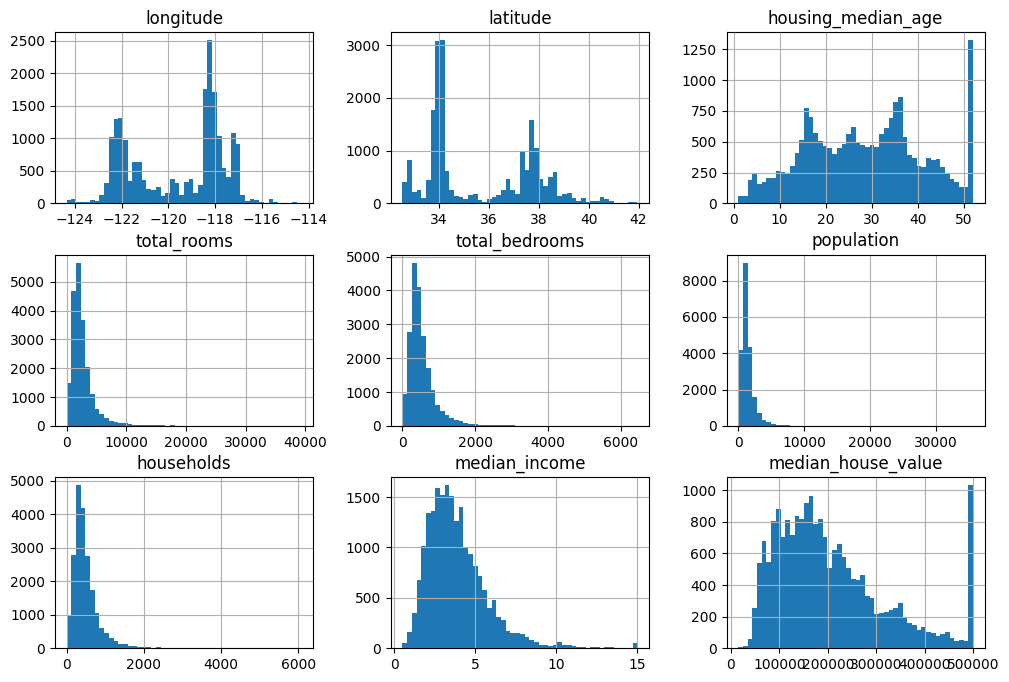

In [6]:
import matplotlib.pyplot as plt

plt.style.use("default")
housing.hist(bins=50, figsize=(12,8))
plt.show()

# 6. 创建测试集
1. 方式1：根据datasets长度做索引打乱以进行一次性划分，采用np.random.permutation()
2. 方式2：根据index采用crc32方式计算hash值，用以划分数据集
3. 方式3：利用数据特性构建hash值，用以划分数据集
4. 方式4：利用Scikit-learn提供的train_test_split()函数
5. 方式5：利用Scikit-learn提供的model_selection包中的拆分函数，如StratifiedShuffleSplit()函数（分层混乱拆分）

## 1. 方式1：根据datasets长度做索引打乱以进行一次性划分，采用np.random.permutation()

In [7]:
import numpy as np

# 把数据随机打乱，然后按比例切分为训练集与测试集
# data：通常是一个 pandas.DataFrame
# test_ratio：测试集占比（例如 0.2 表示 20% 为测试集）

# 设置随机种子
np.random.seed(42)

def shuffle_and_split_data(data, test_ratio):
    # 断言：测试集比例必须在 (0, 1) 之间
    assert 0 < test_ratio < 1, "test_ratio must be between 0 and 1 (exclusive)."

    # np.random.permutation(n)：生成 0 ~ n-1 的一个随机排列数组
    shuffled_indices = np.random.permutation(len(data)) # len(data)：数据的行数（样本数）
    test_set_size = int(len(data) * test_ratio) # 计算测试集大小

    # 断言：测试集大小必须大于 0 且小于总样本数
    assert 0 < test_set_size < len(data), "Invalid test set size computed."

    test_indices = shuffled_indices[:test_set_size] # 取打乱后的前 test_set_size 个索引作为测试集索引。
    train_indices = shuffled_indices[test_set_size:] # 训练集取剩余的部分

    # data.iloc[...]：按行位置索引取数据（支持用整数数组）返回两个 DataFrame：
    return data.iloc[train_indices], data.iloc[test_indices]

* 注意：
    * 如果未加`np.random.seed(42)`运行上述程序会产生问题：**将会生成不同的测试集**
    * 解决方案（也存在问题）：
       1. 在第一次运行时保存测试集，然后在后续运行中加载该测试集
      2. 在调用`np.random.permutation()`之前设计随机数生成器的种子，以始终生成相同的混淆索引
    * 上述两种解决方案在下次获取更新的数据集时会失效，最好的解决方案如下：
        * 使用每个实例的标识符来决定它是否应该进入测试集（假设实例有唯一且不可变的标识符）
            * 例如：
                * **例如,你可以计算每个实例标识符的哈希值,如果哈希值低于或等于最大哈希值的20%,则将该实例放入测试集中。这可确保测试集在多次运行中保持一致,即使你刷新数据集也是如此。新的测试集将包含20%的新实例,但不会包含之前训练集中的任何实例。**
                * “给每一条数据一个固定不变的编号，然后用这个编号算出一个“固定的随机数”。
                * 我们规定：如果这个数落在前 20% 的范围内，就把这条数据放进测试集，否则放进训练集。
                * 因为同一个编号每次算出来的结果都一样，所以不管你运行程序多少次，数据都会被分到同样的集合里。
                * 即使后来数据变多了，旧数据的位置也不会变，只是新加的数据中大约有 20% 会被分到测试集里。”

In [8]:
# 使用shuffle_and_split_data函数
train_set, test_set = shuffle_and_split_data(data=housing, test_ratio=0.2)
print("Train set size: ", len(train_set))
print("Test set size: ", len(test_set))
train_set.head()

Train set size:  16512
Test set size:  4128


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0,NEAR OCEAN
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0,NEAR OCEAN
17445,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,353900.0,NEAR BAY
14265,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,241200.0,<1H OCEAN
2271,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,INLAND


## 2. 方式2：根据index采用crc32方式计算hash值，用以划分数据集
* 利用每个实例的标识符的哈希值来划分训练集

### `in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))`
#### 使用 `apply` 判断样本是否属于测试集


#### 功能说明

该代码用于**逐条判断数据集中每个样本是否应被划分到测试集**，并生成对应的布尔标记结果。

---

#### 执行过程说明

* `ids`：数据集中样本的唯一标识符（ID）列
* `apply()`：对该列中的**每一个 ID**执行一次给定函数
* `lambda id_`：表示当前正在处理的单个样本 ID
* `is_id_in_test_set(id_, test_ratio)`：

  * 根据 ID 的哈希值和测试集比例判断该样本是否进入测试集
  * 返回 `True` 或 `False`

---

#### 返回结果

* `in_test_set` 是一个布尔型 `Series`

  * `True`：该样本被划分到测试集
  * `False`：该样本被划分到训练集

---

#### 使用意义

通过对每个样本 ID 进行独立、确定性的判断，可以保证：

* 多次运行程序时数据划分结果一致
* 数据集更新时，原有训练集样本不会被划入测试集

该方法常用于避免数据泄漏，提升模型评估的可靠性。

---

* 补充：
    * lambda 是 “临时用一下的小函数”，写法是：`lambda 参数: 返回值`

---

### `return data.loc[~in_test_set], data.loc[in_test_set]`
#### 使用布尔索引划分训练集与测试集


##### 1. `in_test_set` 的含义

* 一个与 `data` 行数一致的布尔型 Series
* `True` 表示该样本属于测试集
* `False` 表示该样本属于训练集

---

##### 2. `data.loc[条件]` 的作用

* 根据给定条件筛选行
* 条件为 `True` 的行会被保留下来

---

##### 3. `~in_test_set` 的作用

* `~` 表示逻辑取反
* 将 `True` 变为 `False`，`False` 变为 `True`

---

##### 4. 划分逻辑

* `data.loc[in_test_set]` → 测试集
* `data.loc[~in_test_set]` → 训练集

---

##### 5. 返回结果

* 返回两个 DataFrame：

  * 第一个是训练集
  * 第二个是测试集

---

##### 6. 一句话总结

通过布尔索引，可以根据每一行的判断结果，
将原始数据稳定、无重叠地划分为训练集和测试集。

---

* 补充
    * 一列 = Series，多列 = DataFrame

In [9]:
from zlib import crc32 # 导入 CRC32 哈希函数，crc32 是一种快速、稳定、确定性的哈希函数，非加密哈希，但非常适合做“数据划分”

# 判断“一个 ID 是否应该进测试集”
# crc32(...)：把 ID 映射到一个固定的 32 位哈希值
def is_id_in_test_set(identifier, test_ratio): # identifier：样本的唯一标识符；test_ratio：测试集比例
    return crc32(np.int64(identifier)) < test_ratio * 2**32

# 用哈希规则划分整个数据集
def split_data_with_id_hash(data, test_ratio, id_column): # data：pandas DataFrame；id_column：作为唯一标识符的列名
    # print("type_data" + str(type(data))) # type_data<class 'pandas.core.frame.DataFrame'>
    ids = data[id_column] # 取出 ID 列（Series）
    # print("type_ids" + str(type(ids))) # type_ids<class 'pandas.core.series.Series'>
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    # 等价于下述代码
    # in_test_set = []
    #
    # for id_ in ids:
    #     result = is_id_in_test_set(id_, test_ratio)
    #     in_test_set.append(result)
    return data.loc[~in_test_set], data.loc[in_test_set]

* reset_index() 会**把原来的行索引变成一列**并生成一个新的默认索引

In [10]:
housing_with_id = housing.reset_index()
# print(housing_with_id) # 可以看到索引变为一列
train_set, test_set = split_data_with_id_hash(housing_with_id, test_ratio=0.2, id_column="index")
print(train_set.head())

   index  longitude  latitude  housing_median_age  total_rooms  \
0      0    -122.23     37.88                41.0        880.0   
1      1    -122.22     37.86                21.0       7099.0   
3      3    -122.25     37.85                52.0       1274.0   
4      4    -122.25     37.85                52.0       1627.0   
6      6    -122.25     37.84                52.0       2535.0   

   total_bedrooms  population  households  median_income  median_house_value  \
0           129.0       322.0       126.0         8.3252            452600.0   
1          1106.0      2401.0      1138.0         8.3014            358500.0   
3           235.0       558.0       219.0         5.6431            341300.0   
4           280.0       565.0       259.0         3.8462            342200.0   
6           489.0      1094.0       514.0         3.6591            299200.0   

  ocean_proximity  
0        NEAR BAY  
1        NEAR BAY  
3        NEAR BAY  
4        NEAR BAY  
6        NEAR BAY  


## 使用 `index` 作为 ID 的注意事项

### 1. 当前做法的本质
- 通过 `reset_index()`，将 DataFrame 原有的行索引显式变成了一列（`index`）
- 该列可以作为样本的“唯一标识符”用于哈希划分训练集与测试集
- 这种做法**在教学或演示场景中是可行的**

---

### 2. 使用 `index` 作为 ID 的前提条件
当且仅当满足以下条件时，使用 `index` 作为 ID 才是安全的：
- 数据只允许 **追加（append）**
- 不允许在中间插入新数据
- 不允许重新排序、重建索引或过滤后再 `reset_index()`

否则：
- 原有样本的 index 会发生变化
- 哈希结果改变
- 训练集 / 测试集归属发生变化
- 可能引发 **数据泄漏**

---

### 3. 在中间插入新数据会导致的问题
- 插入操作会整体推移后续样本的 index
- 旧样本的 ID 改变
- 原本在训练集的样本可能进入测试集（反之亦然）
- 破坏基于 ID 的稳定划分假设

---

### 4. 工程级推荐做法
- **不要使用 DataFrame 的 index 作为真实 ID**
- 优先使用：
  - 业务层面的唯一 ID（如 `user_id`, `house_id`）
- 若无业务 ID，可构造稳定 ID：
  - 由不随数据顺序变化的字段生成（如经纬度组合）

---

### 5. 一句话总结
> 用 `index` 当 ID 只在“只追加、不重排”的严格约束下成立；
> 在真实项目中，应使用来源于样本自身的稳定 ID，
> 才能保证训练集与测试集划分长期一致且不发生数据泄漏。

### 6. 例如，用一个地区的经纬度来组成一个ID，如下：

## 3. 方式3：利用数据特性构建hash值，用以划分数据集

In [11]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
# print(housing_with_id)
train_set, test_set = split_data_with_id_hash(housing_with_id, test_ratio=0.2, id_column="id")
print(train_set.values)

[[0 -122.23 37.88 ... 452600.0 'NEAR BAY' -122192.12]
 [1 -122.22 37.86 ... 358500.0 'NEAR BAY' -122182.14]
 [2 -122.24 37.85 ... 352100.0 'NEAR BAY' -122202.15]
 ...
 [20637 -121.22 39.43 ... 92300.0 'INLAND' -121180.57]
 [20638 -121.32 39.43 ... 84700.0 'INLAND' -121280.57]
 [20639 -121.24 39.37 ... 89400.0 'INLAND' -121200.63]]


## 方式4：利用Scikit-learn提供的train_test_split()函数

`train_test_split()`源码

```
def train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
):
    # 1. 参数校验（略）

    n_samples = len(arrays[0])

    # 2. 计算测试集大小
    if test_size is None:
        test_size = 0.25
    n_test = int(n_samples * test_size)

    # 3. 生成索引
    if shuffle:
        rng = np.random.RandomState(random_state)
        indices = rng.permutation(n_samples)
    else:
        indices = np.arange(n_samples)

    # 4. 划分索引
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]

    # 5. 根据索引切分所有输入数组
    result = []
    for array in arrays:
        result.extend([
            array[train_indices],
            array[test_indices]
        ])

    return tuple(result)

```

它与`shuffle_and_split_data()`函数的功能差不多，多了一个random_state参数，它允许设置随机生成器种子，并且`train_test_split()`的本质不是“切数据”，而是“先切索引，再用同一套索引切所有数据”。

In [12]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

* 纯随机的采样会大概率引入采样偏差的风险，故应采用**分层采样**：
    * 定义：将总体分为称为层的同质子组，并从每个层中抽取正确数量的实例以保证测试集能代表总体。
* 假如housing data中的收入中位数（median_income）对于预测房价中位数是一个非常重要的参数，那么在进行分层采样前，应使用pd.cut()函数创建一个收入类别属性，有5个类别（标记从1到5）；类别1的范围从0到1.5（即低于15000美元），类别2的范围从1.5到3，以此类推。


income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64


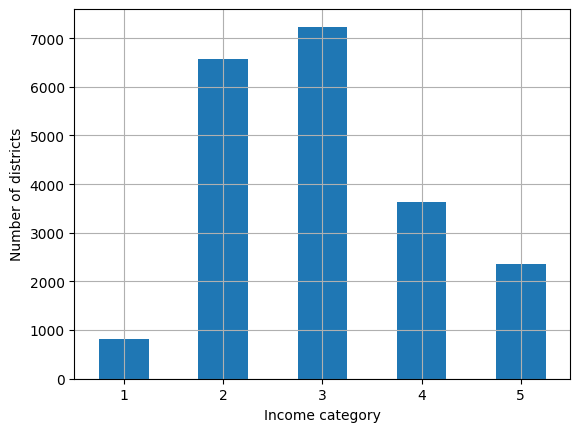

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 把连续的收入变量离散化， 最终得到的新列，是一个类别型变量（Categorical）housing["income_cat"]。
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0, 1.5, 3.0, 4.5, 6., np.inf], # 把收入划分为不同区间，np.inf 表示正无穷
                               labels=[1, 2, 3, 4, 5]) # 给每个区间一个离散标签

print(housing["income_cat"].value_counts().sort_index())

# 1.统计每个收入类别出现的次数（.value_counts()）；2.按类别顺序排序（.sort_index()）；3.绘制柱状图，rot=0：x 轴标签不旋转（保持竖直）
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [14]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


## 5. 方式5：利用Scikit-learn提供的model_selection包中的拆分函数，如StratifiedShuffleSplit()函数（分层混乱拆分）

### sklearn.model_selection包
Scikit-Learn在sklearn.model_selection包中提供了很多拆分类，它们实现了各种策略将数据集拆分为训练集和测试集，每个拆分器都有一个split()方法，该方法返回对相同数据的不同训练/测试拆分的迭代器。

#### `StratifiedShuffleSplit()`
* `StratifiedShuffleSplit()` 是一个：“在随机打乱数据的同时，严格保持类别比例不变的切分器”。
* 核心API如下：
```python
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(
    n_splits=10, # 要生成多少次“独立的分层随机切分”
    test_size=0.2,
    random_state=42
)
```
* 注意：StratifiedShuffleSplit 是“索引生成器”，而不是“数据切分器”。
* 分析其中的n_splits参数：

---

### 1) `n_splits` 到底是什么？一句话先说清

> **`n_splits` 表示：要“重复生成多少次”分层随机切分（train/test 划分）。**
> 每一次切分都会：

* 随机打乱（shuffle）
* 按类别比例分层（stratified）
* 产生一组新的 `(train_indices, test_indices)`

它不是“把数据切成 n 份”，也不是“n 折交叉验证”的那个折数概念。

---

### 2) 为什么需要 `n_splits`？通俗解释

想象你在做实验：

* 你把数据随机划分一次，训练/测试得到一个分数（例如准确率 0.86）
* 但你知道：**随机切分一次的结果可能碰巧好或碰巧差**
* 为了更可靠，你希望：

> “我多随机切几次，每次都保持类别比例一致，然后看模型平均表现。”

这就是 `n_splits` 的意义：

* `n_splits=1`：只切一次（最常见）
* `n_splits=10`：切 10 次（10 组不同的 train/test），得到 10 个评估分数，再求平均

---

### 3) `n_splits` 和 test_size 的关系（直观）

* `test_size=0.2` 决定：**每次切分测试集占 20%**
* `n_splits=5` 决定：**这样的切分重复做 5 次**

注意：
这些切分之间**不是互斥**的（不是把数据分成 5 个互不重叠的测试集）。
不同切分里，某个样本可能这次在测试集、下次在训练集。

---

## 4) 用一个具体例子说明整个 `StratifiedShuffleSplit`

### 例子数据：10 个样本，两个类别 A/B

我们用最简单的分类分层例子：

* 总样本：10
* 类别 A：6 个（60%）
* 类别 B：4 个（40%）

把样本用索引表示：

* A 类：`[0,1,2,3,4,5]`
* B 类：`[6,7,8,9]`

---

### 设置切分器

```python
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=2, test_size=0.2, random_state=42)
```

含义：

* `test_size=0.2` → 每次测试集取 20%：10×0.2=2 个样本
* `n_splits=2` → 生成 2 次不同的切分
* `stratified` → 测试集里也要保持 A:B = 60%:40%

---

### 关键：每次测试集要取多少 A、多少 B？

测试集总共 2 个样本：

* A 类比例 60% → 2×0.6=1.2 ≈ 1 个
* B 类比例 40% → 2×0.4=0.8 ≈ 1 个

所以**每次测试集必须包含：**

* A：1 个
* B：1 个

训练集自然就是剩下的：

* A：5 个
* B：3 个

这就是“分层”的具体含义：**每次切分都维持比例**。

---

### 第 1 次切分（split #1）

假设随机结果选到：

* 测试集：A 选 `[2]`，B 选 `[8]`
* 测试集索引：`[2, 8]`

那么训练集就是剩下的：

* 训练集索引：`[0,1,3,4,5,6,7,9]`

你会发现：

* 测试集：A=1，B=1（比例保持）
* 训练集：A=5，B=3（比例也差不多保持）

---

### 第 2 次切分（split #2）

因为 `n_splits=2`，还会再来一次随机分层切分。

假设第二次选到：

* 测试集：A 选 `[5]`，B 选 `[6]`
* 测试集索引：`[5, 6]`
* 训练集索引：`[0,1,2,3,4,7,8,9]`

同样：

* 测试集依然 A=1，B=1

---

## 5) 这就是 `n_splits` 的“输出形式”

当你运行：

```python
for train_idx, test_idx in sss.split(X, y):
    print(train_idx, test_idx)
```

它会输出 **n_splits 次**：

* 第一次：一组 train/test 索引
* 第二次：另一组 train/test 索引
* …直到 n_splits 次结束

---

## 6) 最常见用法：`n_splits=1`（你只想切一次）

很多教材用：

```python
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
```

原因是：

* 你只需要一个“可靠的分层训练/测试集”
* 不需要重复很多次

---

## 7) 一句话总结 `n_splits`

> **`n_splits` 不是“分成几份”，而是“重复切分几次”。**
> 每次都会生成一套新的、保持类别比例的 train/test 索引。

---

* splitter.split(X, y)：

    * X = housing（只用于提供样本数量）

    * y = housing["income_cat"]（分层依据）

---

```
strat_splits = [
  [train_set_1, test_set_1],
  [train_set_2, test_set_2],
  ...
  [train_set_10, test_set_10]
]
```

In [15]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

strat_splits = [] # 用来保存每一次切分得到的：[训练集 DataFrame, 测试集 DataFrame]
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index] # .iloc[...]：按行位置索引取数据
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])
    print(train_index, test_index)
print("--------------------")
print(strat_splits[1])

[13096 14973  3785 ... 19301 19121 19888] [ 3905 16821  2900 ... 16634  9779  3455]
[12898  9367 19304 ...  9356  7535  3261] [11734  3016 19907 ...  5264  9811   993]
[ 1108 13041 14023 ... 14230  3997 15875] [15389  7193 13314 ... 10546 11151 10640]
[20581  1857  9942 ...  1532  1406  3859] [14190  9837 17881 ... 14140 16175  1598]
[ 9346 12457 16765 ...  9305 20087  3928] [16578  3358  1369 ... 14702   495 10955]
[15191 13992 15445 ... 18711 19772  1096] [ 2256 17567  9009 ... 20309  9003 16106]
[ 6408 17079  9105 ...  9124 17358  3215] [ 1980 10719  7725 ... 18893 15186 10560]
[14758 14246  1868 ...   763 12526 16847] [ 1678  1268  8056 ... 11087 20139  1135]
[ 8147 16627  6352 ... 12324 18267 12790] [19338  9719 20036 ...  2553  8616 19450]
[19887  9051  2502 ...  4591  3656  9393] [ 3804 17282 12044 ...  3225 10033  4082]
--------------------
[       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12898    -117.95     33.84                32.0       1378.0

In [16]:
# 1. 只使用第一个拆分结果
strat_train_set, strat_test_set = strat_splits[0]

print(strat_train_set.info())
print("--------------------------------------------")
print(housing["income_cat"].value_counts() / len(housing))
print("--------------------------------------------")
print(strat_train_set["income_cat"].value_counts() / len(strat_train_set))

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   median_house_value  16512 non-null  float64 
 9   ocean_proximity     16512 non-null  object  
 10  income_cat          16512 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.4+ MB
None
--------------------------------------------
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64
------------------

* 由于分层采样相当普遍，故可以采用更简洁的方法可以使用带有stratify参数的train_test_split()函数来获得单个拆分

```
def train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
):
```

In [17]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

print(strat_train_set["income_cat"].value_counts() / len(strat_train_set))

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64


* 拆分完数据集后删除income_cat列，恢复原始数据集

In [18]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True) # axis=1：表示按列删除,inplace=True表示：直接在原 DataFrame 上修改,不返回新对象

print(strat_train_set)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   
...          ...       ...                 ...          ...             ...   
14207    -118.40     33.86                41.0       2237.0           597.0   
13105    -119.31     36.32                23.0       2945.0           592.0   
19301    -117.06     32.59                13.0       3920.0           775.0   
19121    -118.40     34.06                37.0       3781.0           873.0   
19888    -122.41     37.66                44.0        431.0           195.0   

       population  households  median_income  media

# 7. 探索和可视化数据

* 在划分完测试集后，应探索训练集，如果训练集很大应进行采样

* 由于要实验完整训练集的各种变换，因此需要制作一份原始副本，以便之后可以恢复。

In [19]:
# 备份训练集
housing = strat_train_set.copy()
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.4+ MB
None


## 7.1 可视化数据
* 创建所有地区的散点图来可视化数据

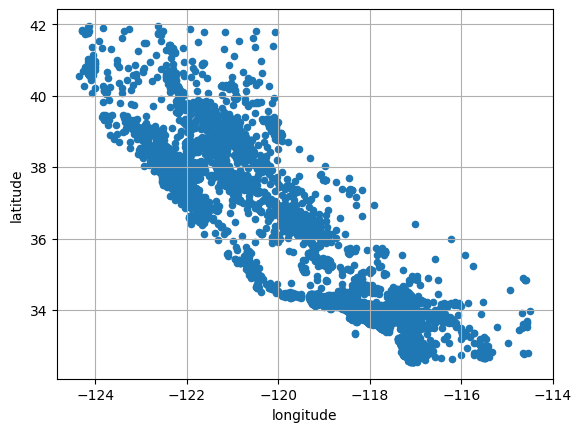

In [20]:
plt.style.use("default")
housing.plot(kind="scatter", x="longitude", y = "latitude", grid=True) # kind 用来指定“用什么类型的图来画数据”。散点图（Scatter Plot）
plt.show()

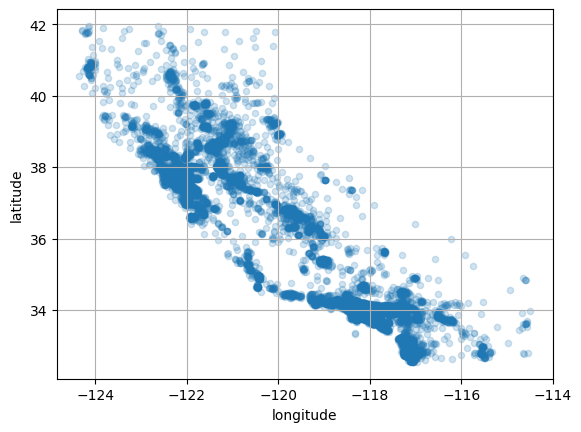

In [21]:
plt.style.use("default")
housing.plot(kind="scatter", x="longitude", y = "latitude", grid=True, alpha=0.2) # alpha 表示“透明度”,alpha = 1.0 → 完全不透明
plt.show()

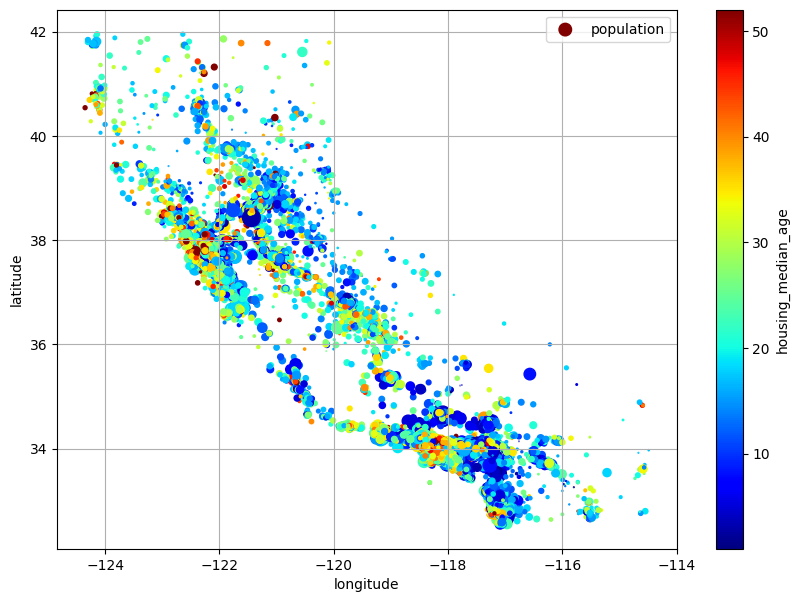

In [22]:
plt.style.use("default")
housing.plot(kind="scatter", x="longitude", y = "latitude", grid=True,
             s=housing["population"] / 100, label="population", # s：scatter中**点的面积**大小,用 人口数 / 100 来缩放, 给“点大小”这个含义一个标签
             c="housing_median_age", cmap="jet", colorbar=True, # c 表示 用哪一列来映射颜色，房价越高 → 颜色越偏向色带的高端；cmap：颜色映射方案（colormap）；"jet" 是一种经典的连续色带：蓝 → 绿 → 黄 → 红；colorbar=True，在图右侧显示 颜色条，颜色 ↔ 数值（房价）的对应关系
             legend=True, sharex=False, figsize=(10, 7)) # legend=True：显示图例；sharex=False：不与其他子图共享 x 轴
plt.show()

* 上图说明：红色为昂贵，蓝色为便宜，圆圈越大代表地区人口越多
* 观察上图，可知道房价与地理位置和人口密度高度相关。

* 对前一幅插图做一个美化版本，在背景中添加了加利福尼亚州图像，采用更美观的标签名称，并去除了网格线。
# 地理数据可视化（可复用模板笔记）

---

### 2️⃣ 通用保存图片函数（强烈推荐）

```python
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
```

**优点**

* 统一管理输出图片
* 默认 300 dpi，适合论文与报告
* 可在整个项目中反复复用

---

## 三、地图背景准备（一次写好，长期可用）

### 3️⃣ 下载并缓存地图图片

```python
import urllib.request

filename = "map.png"
if not (IMAGES_PATH / filename).is_file():
    url = "https://example.com/map.png"
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)
```

**原则**

* 本地已有 → 不再下载
* 保证代码可重复运行

---

## 四、为“展示”重命名列（不污染原数据）

```python
data_vis = data.rename(columns={
    "longitude": "Longitude",
    "latitude": "Latitude",
    "population": "Population",
    "target": "Target value"
})
```

**经验原则**

* 原始数据用于建模
* 重命名版本仅用于可视化 / 展示

---

## 五、多变量散点图（核心模板）

```python
data_vis.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    s=data_vis["Population"] / 100,
    label="Population",
    c="Target value",
    cmap="jet",
    colorbar=True,
    legend=True,
    figsize=(10, 7),
    alpha=0.3
)
```

### 视觉编码规则速记

| 视觉元素  | 表示信息      |
| ----- | --------- |
| x / y | 地理位置      |
| s     | 数值规模（如人口） |
| c     | 目标变量（如房价） |
| alpha | 密度感知      |

---

## 六、叠加地图背景（关键技巧）

### 6️⃣ 读取地图并对齐坐标系

```python
import matplotlib.pyplot as plt

map_img = plt.imread(IMAGES_PATH / filename)

axis = x_min, x_max, y_min, y_max
plt.axis(axis)
plt.imshow(map_img, extent=axis)
```

**关键点**

* `extent` 必须与经纬度范围一致
* 否则地图与散点无法对齐

---

## 七、保存并显示最终图像

```python
save_fig("final_geo_visualization")
plt.show()
```

---

## 八、完整流程速览（背下来就能用）

```text
准备路径
 → 定义保存函数
 → 下载地图
 → 重命名展示列
 → scatter 多变量绘图
 → imshow 叠加地图
 → 保存 + show
```

---

## 九、实战经验总结（非常重要）

1. **地图背景只负责“视觉”，不参与计算**
2. **点大小必须缩放（/100、/1000）**
3. **大量点一定要用 alpha**
4. **可视化列名 ≠ 建模列名**
5. **保存函数一定要统一管理**

---

## 十、一句话终极总结

> 这套模板用于在真实地图坐标系中，将多维数值信息压缩到一张高质量散点图中，是数据探索与结果展示中极具表达力的一种可视化方式。


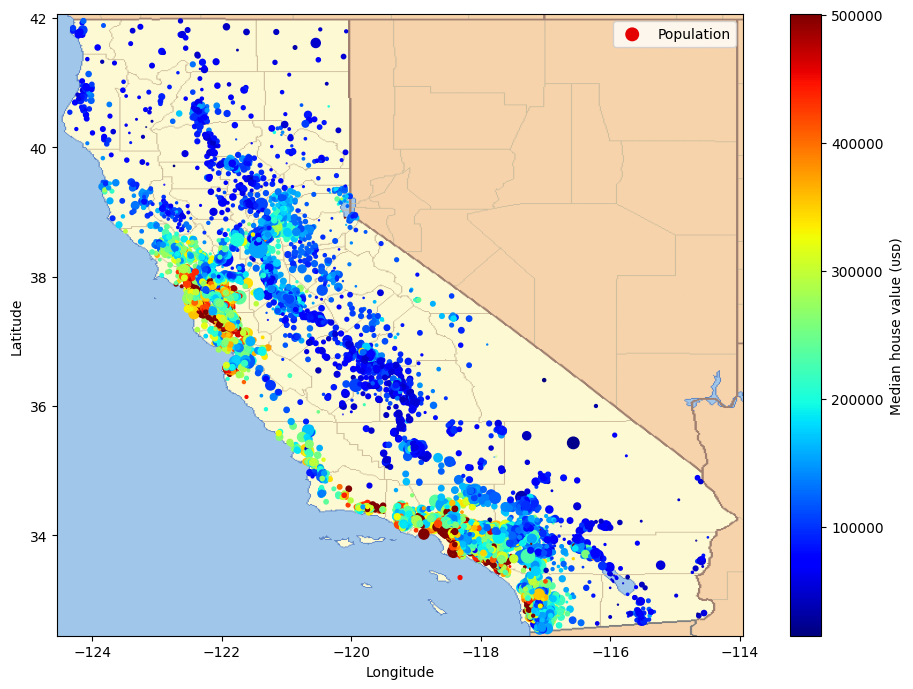

In [23]:
# extra code – this cell generates the first figure in the chapter
plt.style.use("default")
# Download the California image
# 图片保存路径
IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True) # 如果父目录不存在 → 一并创建；如果已存在 → 不报错

# 一个通用的“保存图片函数”
# fig_id：文件名（不含扩展名）；tight_layout：是否自动压缩布局；fig_extension：图片格式（默认 png）；resolution：分辨率（dpi，300 适合论文/印刷）
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}" # 拼出完整保存路径
    if tight_layout:
        plt.tight_layout() # 自动调整子图间距，避免标签被裁剪
    plt.savefig(path, format=fig_extension, dpi=resolution) # 保存当前 Matplotlib 图像

# 下载加州地图背景图片
filename = "california.png"
if not (IMAGES_PATH / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)

# 数据列重命名
housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

# 叠加加州地图背景
california_img = plt.imread(IMAGES_PATH / filename) # 读取地图图片
axis = -124.55, -113.95, 32.45, 42.05 # 设置坐标轴范围，x_min, x_max, y_min, y_max
plt.axis(axis)
plt.imshow(california_img, extent=axis) # extent=axis：把图片“拉伸”到经纬度坐标范围

# 保存并显示最终图像
save_fig("california_housing_prices_plot")
plt.show()

## 7.2 寻找相关性
### 方法1：如果数据不太大，则可以使用`corr()`方法计算出每对属性之间的标准相关系数（也称皮尔逊r）

````markdown
## Pandas `corr()` 方法笔记

### 1. 方法作用
`corr()` 用于计算 **DataFrame 中数值型特征两两之间的相关系数**，
常用于探索性数据分析（EDA）阶段，帮助判断变量之间的线性关系强弱。

---

### 2. 基本用法

```python
corr_matrix = df.corr()
````

* 返回一个 **相关系数矩阵（DataFrame）**
* 行和列均为数值型特征名
* 非数值型列会被自动忽略

---

### 3. 默认相关系数类型

```python
df.corr(method="pearson")
```

* 默认使用 **皮尔逊相关系数（Pearson Correlation）**
* 适合衡量两个连续变量之间的**线性关系**

相关系数取值范围：

| 值  | 含义    |
| -- | ----- |
| +1 | 完全正相关 |
| 0  | 无线性相关 |
| -1 | 完全负相关 |

---

### 4. 常见 `method` 参数

```python
df.corr(method="pearson")   # 默认，线性相关
df.corr(method="spearman")  # 基于秩的相关，适合单调关系
df.corr(method="kendall")   # 非参数相关，适合小样本
```

| 方法       | 适用场景      |
| -------- | --------- |
| Pearson  | 连续变量、线性关系 |
| Spearman | 非线性但单调关系  |
| Kendall  | 小样本、稳健分析  |

---

### 5. 典型使用场景

#### （1）查看某一目标变量的相关性

```python
df.corr()["target"].sort_values(ascending=False)
```

* 快速找出与目标变量关系最强的特征

---

#### （2）特征选择参考

* 高相关特征 → 可能是重要特征
* 低相关特征 → 可能信息量较小（需结合业务判断）

---

### 6. 输出结果的特点

* 对角线元素恒为 `1.0`（变量与自身的相关性）
* 矩阵对称
* 只反映 **线性相关性**

---

### 7. 注意事项（非常重要）

1. **相关性 ≠ 因果关系**
2. `corr()` 无法捕捉非线性复杂关系
3. 强相关特征之间可能存在多重共线性
4. 类别型特征需先编码（如 One-Hot）才能参与计算

---

### 8. 一句话总结

> `corr()` 是一种快速、直观的线性相关性分析工具，
> 常用于建模前的特征探索与筛选，但应结合可视化和业务理解综合判断。

---

* corr()默认采用皮尔逊r(协方差÷(标准差×标准差))计算相关系数r，故只能处理数值型数据，当有下述报错时：“could not convert string to float: 'NEAR BAY'”说明DataFrame中包含了非数值型列，在该环境下它无法自动忽略该值，应手动处理

In [24]:
# 先计算数据集中各数值特征之间的相关系数矩阵，
# 再查看“房价中位数”与其他特征的相关程度，并按强弱排序。
corr_matrix = housing.corr(numeric_only=True) # 显式告诉 corr() 只用数值列

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

### 方法2：使用Pandas的scatter_matrix()函数，它可以将每个数值属性与其他每个数值属性进行对比。

````markdown
## Pandas `scatter_matrix()` 方法笔记

### 1. 方法作用
`scatter_matrix()` 用于 **同时可视化多个数值型特征之间的两两关系**，
是探索性数据分析（EDA）中常用的快速检查工具。

它可以帮助你：
- 发现特征之间的相关关系（线性 / 非线性）
- 观察单变量分布形态
- 识别异常值（outliers）

---

### 2. 基本用法

```python
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(12, 8))
````

* `df`：`pandas.DataFrame`
* 只会使用 **数值型列**
* 字符串 / 类别列会被自动忽略

---

### 3. 输出图像结构说明

生成的是一个 **N × N 的矩阵图**（N 为数值特征个数）：

* **对角线**：

  * 每个特征自身的分布
  * 默认显示直方图（Histogram）
* **非对角线**：

  * 两个不同特征之间的散点图（Scatter Plot）

示意结构：

```
        A        B        C
A     hist     scatter   scatter
B   scatter     hist     scatter
C   scatter   scatter     hist
```

---

### 4. 常用参数

| 参数         | 作用                            |
| ---------- | ----------------------------- |
| `figsize`  | 控制整体图像大小                      |
| `alpha`    | 设置散点透明度，避免重叠                  |
| `diagonal` | 控制对角线显示方式（`"hist"` / `"kde"`） |
| `marker`   | 设置散点样式                        |

示例：

```python
scatter_matrix(
    df,
    figsize=(12, 8),
    alpha=0.2,
    diagonal="kde"
)
```

---

### 5. 典型使用场景

#### （1）相关性探索

* 点云呈斜线 → 可能存在强相关
* 点云呈圆团 → 相关性弱

#### （2）发现非线性关系

* 即使 `corr()` 值很小
* 也可能在散点图中看到曲线或分段趋势

#### （3）检查异常值

* 孤立点、极端点一眼可见

#### （4）查看分布形态

* 偏态
* 长尾
* 是否需要对数变换

---

### 6. 与 `corr()` 的对比

| 方法                 | 输出   | 优点    | 局限   |
| ------------------ | ---- | ----- | ---- |
| `corr()`           | 数值矩阵 | 快、定量  | 仅线性  |
| `scatter_matrix()` | 图像矩阵 | 直观、全面 | 不给数值 |

**推荐组合使用**：

```text
corr() → 定量筛选
scatter_matrix() → 形态确认
```

---

### 7. 使用建议（经验总结）

1. 特征较多时，**先筛选关键列**
2. 数据量大时，降低 `alpha`
3. 结果只用于探索，不直接作为结论
4. 建模前使用，避免“盲目选特征”

---

### 8. 一句话总结

> `scatter_matrix()` 是一种高效的多变量可视化工具，
> 能在建模前快速揭示特征之间的关系结构，是 EDA 阶段的重要手段。



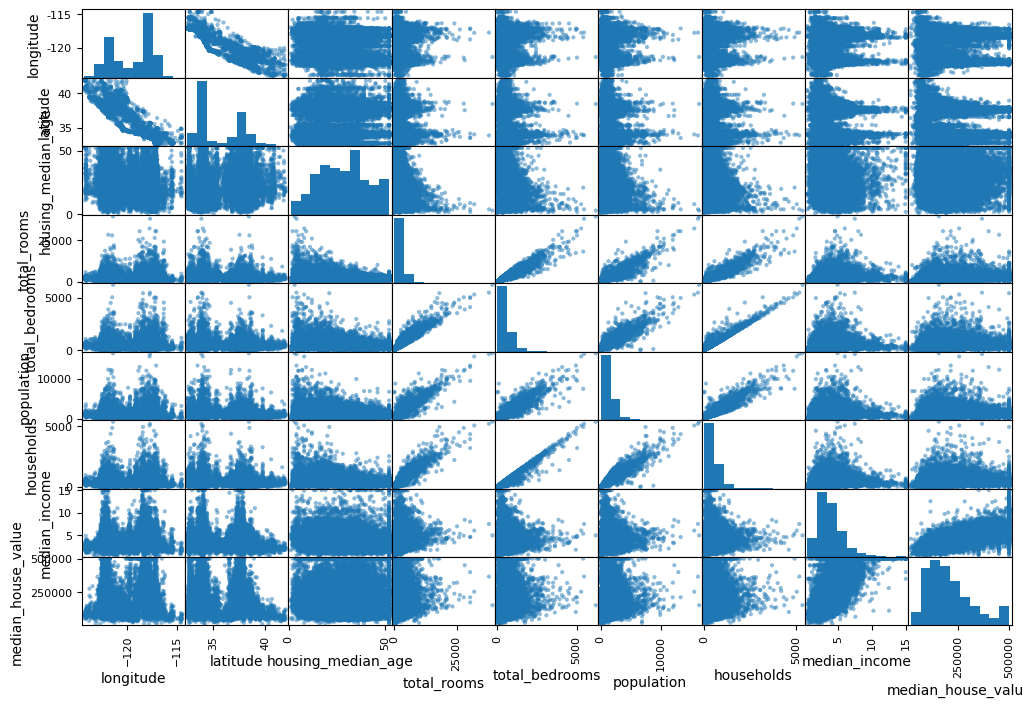

In [25]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing, figsize=(12, 8))
plt.show()

* 根据scatter_matrix的结果可以看出，与房价中位数相关的最正相关的是收入中位数（呈正斜线），放大该散点图

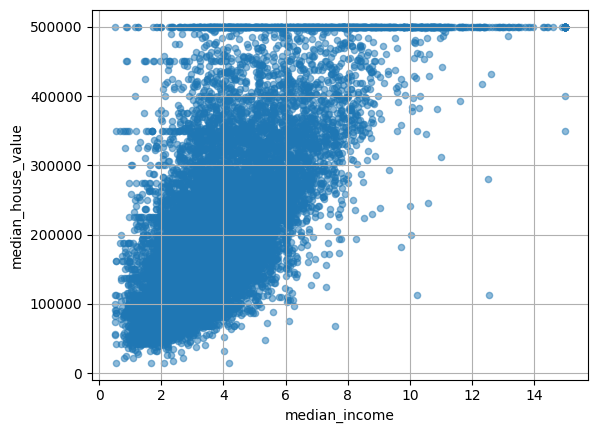

In [26]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.5, grid=True) # alpha 表示“透明度”
plt.show()

## 7.3 实验不同属性组合

In [27]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"] # 每户房间数
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing['total_rooms'] # 卧室比例
housing["people_per_house"] = housing["population"] / housing["households"] # 每户人口数

print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity  rooms_per_house  bedrooms_ratio  people_per_house  
13096        NEAR BAY         3.211799   

In [28]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

## 8. 为机器学习算法准备数据
* 为准备数据编写一个函数，原因如下：
    * 可以在任何数据集上轻松地重现这些转换（如下次获得新的数据集时）
    * 可以逐步构建一个可以在未来项目中重复使用的转换函数库
    * 可以在实时系统中使用这些函数来转换新的数据，再将其提供给算法
    * 可以轻松尝试各种转换并查看哪种转换组合效果最好
1. 清洗数据（处理数值特征缺省值）
2. 处理文本和类别属性
3. 特征缩放和转换
4. 定制转换器
5. 转换流水线（Pipeline）

In [29]:
housing = strat_train_set.drop("median_house_value", axis=1) # drop() 用来从 DataFrame 或 Series 中“删除指定的行或列”。注意：drop()创建数据的副本并且不会影响strat_train_set。
housing_label = strat_train_set["median_house_value"].copy()

# print(housing)
print(housing_label)

13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
           ...   
14207    500001.0
13105     88800.0
19301    148800.0
19121    500001.0
19888    233300.0
Name: median_house_value, Length: 16512, dtype: float64


## 8.1 清洗数据-处理缺省值
* 1. 当有属性有缺省值时，可考虑3种解决方法：
    * 1. 去掉相应的地区
        * `.dropna()`: 用于删除包含缺失值（NaN）的行或列。
            * 如：`housing.dropna(subset=["total_bedrooms"], inplace=True)`会将删除 housing 中所有 total_bedrooms 为缺失值（NaN）的行，并直接在原 DataFrame 上生效。inplace=True表示直接修改 housing 本身，不返回新的DataFrame
    * 2. 去掉整个属性
            * `.drop("total_bedrooms", axis=1)`直接删除这一列
    * 3. 将缺省值设置为某个值（零、均值、中位数等）。这称为归责（破坏性最小，适用）
            * `.fillna()`用于“填补缺失值（NaN）”
            * 如`housing.fillna({"total_bedrooms": housing["total_bedrooms"].median()}, inplace=True) `取中值填补


In [30]:
housing.info() # 可观察到total_bedrooms有一些缺省值

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


* 使用Scikit-Learn类SimpleImputer：将存储每个特征的中位数值，不仅可以在训练集上估算缺失值，而且可以在验证集、测试集和任何提供给模型的新数据上估算缺失值。
* 仅能根据数值属性来计算中位数
* SimpleImputer会简单计算每个属性的中位数并将结果存储在它的statistics_实例变量中
* 还有KNNImputer：将每个缺省值替换为该特征的k近邻的平均值。该距离和基于所有可用的特征
* 还有IterativeImputer：为每个特征训练一个回归模型，以根据所有其他可用特征预测缺省值。然后，它会根据更新后的数据再次训练模型，并多次重复该过程，在每次迭代中改进模型和替换值。

In [31]:
# 使用SimpleImputer填补缺失值
from sklearn.impute import SimpleImputer

# 创建一个SimpleImputer实例
imputer = SimpleImputer(strategy="median") # 也可以是最频繁的值(strategy="most_frequent")；也可以是常数值（strategy="constant", fill_value=...）

# 创建仅包含数值属性的数据副本，排除文本属性ocean_proximity
housing_num = housing.select_dtypes(include=[np.number])
# print(housing_num.info())

# 使用fit()将imputer实例拟合到训练数据中
imputer.fit(housing_num)

print(imputer.statistics_)
print(housing_num.median().values)
print(imputer.feature_names_in_)

# 将imputer学习到的中位数替换缺失值来转换数据集
X = imputer.transform(housing_num)

X.shape


[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]
[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]
['longitude' 'latitude' 'housing_median_age' 'total_rooms'
 'total_bedrooms' 'population' 'households' 'median_income']


(16512, 8)

* `imputer.fit(housing_num)`说明
    * 对 housing_num 的每一列，逐列执行：
        * 找出非缺失值
        * 计算该列的 中位数
        * 把这个中位数存下来
* `transform()`说明：
    * 对 housing_num 的每一列，逐列执行：
        * 找到缺失值（NaN）
        * 查找该列对应的中位数（来自 imputer.statistics_）
        * 用这个中位数 替换 NaN
        * 非缺失值保持不变
    * 返回的是一个 NumPy ndarray，而不是 DataFrame
* 也可以直接用`fit_transform()`方法，它所做的就是先`fit()`再`transform()`

In [32]:
# 将转换器所输出的Numpy数组（有时是Scipy稀疏矩阵）x包装在DataFrame中，并从housing_num中恢复列名和索引
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

print(housing_tr.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB
None


## 8.2 处理文本和类别属性
* 目前只处理了数字属性，但数据集中可能还包含文本属性。在该数据集中，只有一个：ocean_proximity属性

In [33]:
# 查看该属性
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

print(type(housing_cat))

<class 'pandas.core.frame.DataFrame'>


In [34]:
# 大多数机器学习算法更喜欢处理数字，所以将这些类别属性从文本转换为数字
# 使用Scikit-Learn中的OrdinalEncoder类
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

print(housing_cat_encoded) # 返回的是Numpy数组

# 使用categories_实例变量获取类别列表
# ordinal_encoder.categories_

# 再转换为DataFrame
housing_cat_encoded_tr = pd.DataFrame(housing_cat_encoded, columns=housing_cat.columns,
                                      index=housing_cat.index)

print(housing_cat_encoded_tr.head(8))
print(housing_cat.value_counts())


[[3.]
 [0.]
 [1.]
 ...
 [4.]
 [0.]
 [4.]]
       ocean_proximity
13096              3.0
14973              0.0
3785               1.0
14689              1.0
20507              4.0
1286               1.0
18078              0.0
4396               3.0
ocean_proximity
<1H OCEAN          7274
INLAND             5301
NEAR OCEAN         2089
NEAR BAY           1846
ISLAND                2
Name: count, dtype: int64


* 注意：上述这种使不同文本转换为数字的方法并不可取，因为这会导致两个距离较近的值比两个距离较远的值更相似。
* 在某些情况下可能没问题（如，对于有序类别（如“坏”、“平均”、“好”和“优秀”））
* 但对于ocean_proximity就会出现问题，因为类别互相没有关系
* 解决方案：
    1. 为每个类别创建一个二进制属性：当类别为“<1H OCEAN ”时，这个属性等于1（否则为0）；当类别为“INLAND”时，另一个属性等于1（否则为0），以此类推，这称为独热编码（OneHotEncoder）。因为只有一个属性会等于1（热），而其他属性将为0（冷）。新属性有时称为虚拟属性。Scikit-Learn提供了OneHotEncoder类将类别值转换为独热向量：
    2. pandas有一个get_dummies()函数，它将每个分类特征转换为独热表示，每个类别有一个二元特征（0/1）。但是它只是表格处理工具，并不能像OneHotEncoder那样记住经过了哪些类别的训练，不可控
* 当分类属性包含大量可能的类别时，采用独热编码会导致大量的输入特征，会减慢训练速度并降低性能。
* 解决方案：
    1. 如将ocean_proximity特征转换为到海洋的距离的方法转换为数值属性
    2. 使用category_encoders包提供的编码器
    3. 用嵌入的可学习的低维向量替换每个类别（13和17节会讲到）

In [35]:
# OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse_output=False) # 可设置参数`sparse=False`，会使transform()返回常规的Numpy数组
housing_cat_1hot = cat_encoder.fit_transform(housing_cat) # 返回的是稀疏矩阵

print(housing_cat_1hot) # .toarray() 把 稀疏矩阵转换为 普通 NumPy 二维数组

# 与OrdinaryEncoder一样，可使用编码器的categories_实例变量获取类别列表
cat_encoder.categories_

[[0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]


[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [36]:
# pandas.get_dummies()
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})

pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [37]:
# 看二者对于未知列的处理
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "NEAR BAY"]})

In [38]:
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [39]:
# OneHotEncoder会处理未知列x，需将handle_unknown设置为ignore，将用0表示未知列
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

* 当使用DataFrame拟合任何Scikit-Learn估计器时，估计器会将列名称存储在`feature_names_in_`属性中。Scikit-Learn会确保之后馈送到该估计器的任何DataFrame具有相同的列名。
* Transformer还提供了get_feature_names_out()方法，提供用于构建DataFrame的列名

In [40]:
# feature_names_in
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [41]:
# get_feature_names_out()
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [42]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [43]:
# 构建DataFrame
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown),
                         columns=cat_encoder.get_feature_names_out(),
                         index=df_test_unknown.index)
df_output

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0


## 8.3 特征缩放和转换

* 两种方法：
    1. 最小-最大缩放
    2. 标准化
    3. 当特征分布有一个重尾时，可采用分桶策略
    4. 当特征具有多峰分布(即有两个或更多清晰的峰(也称为模式))时，也可将其进行分桶
    5. 当特征具有多峰分布，另一种方法时为每个模式（至少是主要模式）添加一个特征
    6. 使用Scikit-Learn的转换器（inverse_transform()和TransformedTargetRegressor()）

---

* 注意：
* 缩放器与所有估计器一样，是把缩放器拟合到训练数据。**永远不要对训练集以外的任何其他对象使用`fit()`或`fit_transform()`**
* 一旦有了一个训练好的缩放器，就可以用它来`transform()`任何其他集合（包括验证集、测试集和新数据）
* 虽然训练集会最终缩放到指定范围，如果新数据包括异常值，这些值可能会在范围之外。可将clip超参数设置为True即可避免（即将超出范围的值定为区间边界）。

---

* 不仅要对输入特征进行特征缩放和转换，目标值也可能还需要转换

In [44]:
housing_tr.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,537.881298,1425.513929,499.990189,3.870428
std,2.000624,2.133294,12.585738,2185.287466,421.831667,1094.795467,382.865787,1.891936
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.800000,33.930000,18.000000,1447.000000,297.000000,787.000000,279.000000,2.562500
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500
75%,-118.010000,37.720000,37.000000,3154.000000,642.000000,1726.000000,603.000000,4.750000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100


* 观察到房间总数（total_rooms）大约在6\~39320之间，收入中位数（median_income）在0\~15之间，如果不进行缩放，那么大多数模型将偏向于忽略收入中位数并更关注房间总数。

### 8.3.1. 最小-最大缩放（归一化）
* 通过减去最小值并除以最小值和最大值之间的差值来执行

---

## MinMaxScaler 的作用与实现逻辑（源码视角）

`MinMaxScaler` 的目标是对每一列特征做逐列（per-feature）的线性缩放。它在 `fit` 阶段只做两件事：

1. 统计每个特征在训练集上的最小值与最大值，并缓存为内部状态

   * 训练集最小值：$x_{\min}$（对应属性 `data_min_`）
   * 训练集最大值：$x_{\max}$（对应属性 `data_max_`）
   * 训练集范围：$x_{\max}-x_{\min}$（对应属性 `data_range_`）

2. 根据目标区间 `feature_range=(a,b)` 计算线性变换所需的系数，并缓存为

   * `scale_`：把原始尺度拉伸/压缩到目标区间的比例
   * `min_`：把数据平移到目标区间起点的偏置

在 `transform` 阶段，它对新数据逐列应用同一组 `scale_` 与 `min_`，即“训练集学到的缩放规则”，不会再重新统计极值。

缩放（默认映射到 $[0,1]$）可写为：

$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

实现上等价于：先减去训练集最小值，再除以训练集范围（并在设置了目标区间时额外乘以区间宽度并加上偏置）。

---

## 关键参数（构造函数）

* `feature_range=(0, 1)`
  指定输出映射区间的下界与上界。必须满足下界 < 上界。常见用法如 `(0,1)`、`(-1,1)`。

* `copy=True`
  是否在变换时复制输入数据。`True` 更安全（不改原数组），`False` 可能原地修改以节省内存（取决于输入类型与内部实现路径）。

* `clip=False`
  若为 `True`，则在 `transform` 后把输出裁剪到 `feature_range` 内。
  使用场景：测试集出现了超出训练集范围的值时，缩放结果可能落在区间外（例如 >1 或 <0）；开启 `clip` 可强制截断到区间边界。
  代价：信息被压扁在边界上，可能影响模型对极端值的区分。

---

## `fit/transform` 后的核心属性（你在调试时最常用）

* `data_min_`：每个特征在训练集上的最小值向量
* `data_max_`：每个特征在训练集上的最大值向量
* `data_range_`：每个特征的范围（`data_max_ - data_min_`）
* `scale_`：每个特征的缩放系数（与 `feature_range` 相关）
* `min_`：每个特征的平移项（与 `feature_range` 相关）
* `n_features_in_`：训练时看到的特征数量（用于一致性检查）

---

## 边界与数值稳定性（实现细节）

* 常量特征（某列满足 $x_{\max}=x_{\min}$）
  这会导致分母为 0。实现中会对该列做保护：把该列的缩放比例按“安全方式”处理，使变换结果不会产生除零错误；直观效果是该列变换后成为一个常数（通常对应到目标区间的下界或某个固定值，取决于内部处理与区间设置）。

* 对异常值敏感
  因为它直接依赖训练集极值 $x_{\min}, x_{\max}$。一两个极端点就可能把绝大多数样本压缩到很窄的区间，尤其在长尾数据（如电力负荷尖峰、传感器瞬态噪声）中更明显。

---

## 使用规范（工程/论文里建议写法）

* 只在训练集上 `fit`：用训练集学到的 $x_{\min}, x_{\max}$ 去缩放训练/验证/测试，避免数据泄漏。
* 若预期部署数据可能超出训练范围：考虑 `clip=True` 或者改用对异常值更稳健的缩放方案（如 RobustScaler）。






In [45]:
housing_num.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100


In [46]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(0, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [47]:
housing_num_min_max_scaled

array([[0.19574037, 0.55851064, 1.        , ..., 0.09649123, 0.19283181,
        0.11026055],
       [0.60547667, 0.16914894, 0.76470588, ..., 0.04066986, 0.06645511,
        0.38535331],
       [0.24036511, 0.61808511, 0.62745098, ..., 0.03429027, 0.03770767,
        0.1333154 ],
       ...,
       [0.73935091, 0.00425532, 0.23529412, ..., 0.17243283, 0.14168378,
        0.24563109],
       [0.60344828, 0.1606383 , 0.70588235, ..., 0.10563121, 0.15624417,
        0.25141722],
       [0.19675456, 0.54361702, 0.84313725, ..., 0.04165133, 0.03938772,
        0.19195597]])

In [48]:
min_max_scaler.data_min_

array([-124.35  ,   32.55  ,    1.    ,    2.    ,    1.    ,    3.    ,
          1.    ,    0.4999])

In [49]:
min_max_scaler.data_max_

array([-1.14490e+02,  4.19500e+01,  5.20000e+01,  3.93200e+04,
        6.21000e+03,  1.63050e+04,  5.35800e+03,  1.50001e+01])

In [50]:
min_max_scaler.data_range_

array([9.86000e+00, 9.40000e+00, 5.10000e+01, 3.93180e+04, 6.20900e+03,
       1.63020e+04, 5.35700e+03, 1.45002e+01])

In [51]:
min_max_scaler.n_samples_seen_

16512

## 8.3.2. 标准化
* 首先减去平均值（因为标准化均值为0），然后将结果除以标准差（因此标准化值的标准差等于1）。与最小-最大缩放不同，标准化不会将值限制在特定范围内，但是，标准化受异常值影响要小很多。

---

## StandardScaler 的作用与实现逻辑（源码视角）

`StandardScaler` 用于对特征进行**标准化（Standardization）**，即将每一列特征变换为**均值为 0、标准差为 1** 的分布形式。它并不限定数据的取值范围，而是通过消除均值和尺度差异，使不同特征在统计意义上具有可比性。

在 `fit` 阶段，`StandardScaler` 对训练数据逐列完成以下统计并缓存结果：

1. 计算每个特征的均值

   * 均值：$\mu$（对应属性 `mean_`）

2. 计算每个特征的标准差

   * 标准差：$\sigma$（对应属性 `scale_`，本质是方差的平方根）

在 `transform` 阶段，新数据直接使用训练阶段得到的 $\mu$ 与 $\sigma$ 做线性变换，不再重新估计统计量。

标准化变换定义为：

$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

变换后，每个特征在训练集上的统计特性满足“零均值、单位方差”。

---

## 关键参数（构造函数）

* `with_mean=True`
  是否在变换前减去特征均值。
  若设为 `False`，则只做尺度缩放而不做中心化，常用于稀疏矩阵（避免破坏稀疏结构）。

* `with_std=True`
  是否除以标准差。
  若设为 `False`，则仅进行均值中心化。

* `copy=True`
  是否复制输入数据。`True` 更安全，`False` 可能原地修改数据以节省内存。

---

## `fit/transform` 后的核心属性

* `mean_`：训练集上每个特征的均值向量
* `scale_`：训练集上每个特征的标准差向量
* `var_`：训练集上每个特征的方差向量
* `n_features_in_`：训练阶段看到的特征数，用于输入一致性校验

---

## 数值与边界处理要点

* 常量特征（$\sigma = 0$）
  对于方差为 0 的特征，内部实现会避免除零错误，该特征在变换后通常变为全 0 列，对模型不再产生影响。

* 对异常值仍然敏感
  虽然不像 MinMaxScaler 那样依赖极值，但均值和标准差本身仍会被极端样本拉偏，只是影响方式不同。

---

## StandardScaler 与 MinMaxScaler 的主要区别（简要）

* 缩放目标不同

  * StandardScaler：使特征满足零均值、单位方差
  * MinMaxScaler：将特征映射到固定区间（如 $[0,1]$）

* 对数据分布的影响不同

  * StandardScaler 不限制取值范围，结果可能为任意实数
  * MinMaxScaler 输出范围固定，但会压缩分布

* 对模型的适配性不同

  * StandardScaler 更适合线性模型、SVM、逻辑回归、PCA 等依赖数据分布和方差结构的方法
  * MinMaxScaler 更常用于 KNN、神经网络等对数值尺度敏感、但不要求高斯分布的模型

一句话总结：
**StandardScaler 关注“统计尺度一致性”，MinMaxScaler 关注“数值范围一致性”。**


In [52]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [53]:
type(housing_num_std_scaled)

numpy.ndarray

In [54]:
housing_num_std_scaled

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.13746004,
         1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.69377062,
        -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.78876841,
        -0.77572662, -0.75978881],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  1.26829911,
         0.67913534,  0.1010487 ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.27356264,
         0.88286825,  0.14539615],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.67915557,
        -0.75221898, -0.31034135]])

---

## 一、机器学习不喜欢**信息被压缩**

当你把特征缩放到一个很小的范围（例如接近 0 的一段区间）时，常见后果是：

> **大量原本有差异的样本，在数值上变得几乎不可区分**

这在模型看来，相当于**特征信息损失**。

---

## 二、从优化角度看：梯度变得“没区分度”

对大多数模型（线性模型、神经网络）来说，参数更新依赖梯度：

* 特征值越接近 0
* 梯度项越小
* 参数更新幅度越弱

如果缩放后：

* 绝大多数样本的特征值都挤在 $[0, 0.01]$
* 不同样本之间差异极小

那么模型在反向传播或梯度下降时会出现：

* 梯度几乎一致
* 学不到“谁比谁更重要”
* 收敛慢，甚至学不到有效参数

---

## 三、从几何角度看：距离和相似性失真

很多算法依赖**距离或内积**：

* KNN
* KMeans
* SVM（核方法）
* 线性模型的判别函数

当特征被压缩到很小的区间时：

* 样本间的欧氏距离被整体压扁
* 原本“明显不同”的点，在几何空间中变得几乎重合
* 相似性度量失去判别力

这不是“尺度统一”的问题，而是**尺度统一得过头**。

---

## 四、重尾数据下的问题会被放大（这是关键）

在重尾分布中，使用基于极值的缩放（如 Min-Max）会导致：

* 一个极端大值决定整个区间
* 绝大多数样本被压到非常靠近 0 的位置

例如：

* 正常样本：3、4、5
* 极端样本：500

缩放后：

* 3 → 0.006
* 4 → 0.008
* 5 → 0.010

对模型来说：

> 3、4、5 几乎是“同一个数”

这就是机器学习真正“讨厌”的地方。

---

## 五、与 StandardScaler 的对比理解

* **MinMaxScaler（小范围）**

  * 强制限制数值区间
  * 容易压缩信息
  * 对极端值非常敏感

* **StandardScaler（不限制范围）**

  * 保留数值差异
  * 让特征在统计尺度上可比
  * 允许“重要样本”在数值上凸显

因此在很多模型中，更关心的是：

> **相对变化是否被保留，而不是数值是否落在 [0,1]**

---

## 六、什么时候“小范围缩放”是合理的

机器学习并非一概反对小范围，只是在**特定前提下才合适**：

* 特征本身没有重尾
* 没有极端值
* 模型对数值范围非常敏感（如部分神经网络）
* 数据已经过对数/分位数等预处理

---

## 七、一句话总结（核心结论）

> **机器学习不喜欢“在缩放过程中把大量样本的信息压扁到几乎没有区分度”。**



* 所以当特征的分布有一个 **重尾(heavy tail)** 时（即当远离平均值的值不是指数级稀有时），机器学习并不喜欢直接将特征进行缩放
* 所以在特征缩放前，应首先对其进行变换来缩小重尾，并尽可能的使分布大致对称。
    * 方法1(平方根替换)：用它的平方根来替换特征（或将特征提升到0~1之间的幂）
    * 方法2（对数替换）：如果该特征有一个很长很重的尾巴，例如幂律(power law)分布，那么用对数替换该特征可能会好一些
    * 方法3（对特征进行分桶(bucketizing)）：即将其分布分为大致相等大小的桶，并且用它所属的桶的索引替换每个特征值，类似之前创建`income_cat`所做的采用分层采样处理类别特征（例如：将每个值替换为其百分位数）。使用大小相等的桶进行分桶会产生几乎均匀分布的特征，因此无需进一步缩放，或者可以仅除以桶的数量来强制值在0~1范围内。

---

补充：
* 幂律分布是一类概率分布，其核心特征是：随机变量取到大值的概率，随着数值增大按幂函数形式衰减，而不是指数形式衰减。公式如下：
$$
P(X = x) \propto x^{-\alpha}, \quad x \ge x_{\min}
$$
* 幂律分布是重尾分布的一种典型形式。

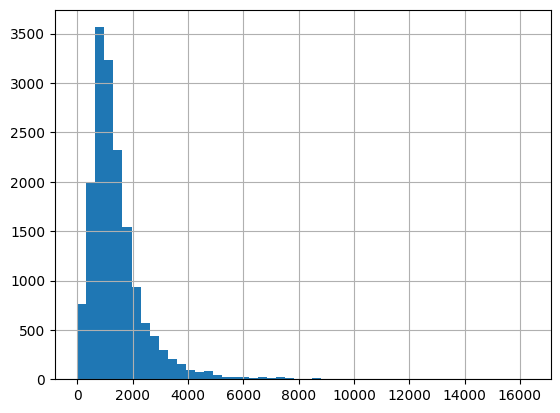

In [55]:
# population大致遵循幂律分布
housing["population"].hist(bins=50)
plt.show()

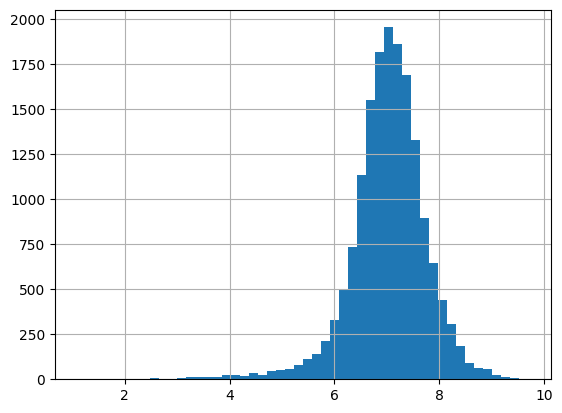

In [56]:
# 改为对数替换该特征看起来接近高斯分布
housing["population"].apply(np.log).hist(bins=50)
plt.show()

---

## 什么是对重尾特征进行分桶（bucketizing）

**分桶（bucketizing）**是指：
将连续型、取值跨度极大、呈重尾特征的数值变量，**按区间划分为若干离散桶（bucket）**，并用桶编号或桶标签来表示原始数值。

其核心思想是：

> **不再精确建模“有多大”，而是建模“属于哪个数量级或区间”。**

---

## 为什么分桶适合处理重尾特征

重尾特征的典型问题是：

* 大多数样本集中在很小范围
* 少数极端值跨度巨大
* 极端值主导统计量和模型行为

分桶的作用在于：

* **削弱极端值的数值影响**
* **保留“等级/区间”层面的信息**
* **避免模型被尾部数值拉偏**

换句话说，分桶把“连续的巨大差异”转化为“有限的类别差异”。

---

## 分桶的基本形式

设原始特征为 $x$，取值范围极大，可以将其映射为桶编号 $b(x)$：

$$
b(x) = k \quad \text{if } x \in [t_k, t_{k+1})
$$

其中：

* ${t_0, t_1, \dots, t_K}$ 是预先定义的分桶边界
* $k$ 为桶索引或桶标签

---

## 常见的分桶策略

### 1. 等宽分桶（Equal-width）

* 每个桶覆盖相同的数值区间
* 形式简单
* 在重尾数据中，**高值桶往往极度稀疏**

适合：
取值范围可控、尾部不极端的情况

---

### 2. 等频分桶（Equal-frequency / Quantile）

* 每个桶包含近似相同数量的样本
* 自动适应重尾结构
* 在尾部给出更细的区分能力

适合：
**典型重尾特征**

---

### 3. 对数量级分桶（Log / Power bucket）

* 按数量级或指数区间划分
  例如：$[1,10)$、$[10,100)$、$[100,1000)$
* 特别适合幂律或极端重尾分布

适合：
跨度跨多个数量级的特征

---

## 分桶后的特征表达方式

分桶本身只是**区间映射**，后续通常有两种用法：

* **直接用桶编号作为数值特征**
  表达“等级高低”

* **One-Hot / Embedding 表示**
  把桶当作类别特征使用

具体选哪种，取决于模型是否能处理离散特征。

---

## 分桶处理重尾特征的优点

* 极大降低极端值的影响
* 提升模型稳定性与鲁棒性
* 对树模型、规则模型尤其友好
* 解释性强（区间含义直观）

---

## 分桶的代价与注意点

* **信息损失**
  桶内样本的细微差异被忽略

* **边界敏感**
  不合理的分桶边界会引入人为偏差

* **需要经验或数据驱动设计**
  尤其是桶数量与边界选择

---

## 一句话总结

> **分桶通过将重尾连续特征映射为有限区间等级，削弱极端值影响，用结构化区间信息替代精确数值，是处理重尾特征的有效方法之一。**



### 8.3.3. 当特征分布有一个重尾时，可采用分桶策略
* 采用百分位数对重尾特征进行分桶

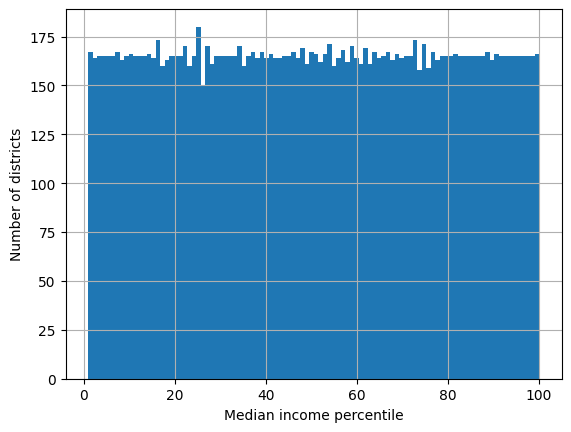

In [57]:
# 计算1%到99%的分位数，得到一组按数据分布自适应的切分边界（即按样本数量均匀切分）。
percentiles = [np.percentile(housing["median_income"], p)
               for p in range(1, 100)]
# 把连续的`median_income`按分位数边界切分成100个桶，并用1–100的整数标签表示桶编号。
flattered_median_income = pd.cut(housing["median_income"],
                                  bins=[-np.inf] + percentiles + [np.inf], # np.int 正无穷；使用正负无穷作为兜底边界，避免极端值落在分桶范围之外
                                  labels=range(1, 100 + 1))
flattered_median_income.hist(bins=100) # 为series绘制直方图
plt.xlabel("Median income percentile")
plt.ylabel("Number of districts")
plt.show()
# 注：低于第1百分位的收入标记为1，高于第99百分位的收入标记为100。因此下图所示分布范围为1至100（而非0至100）。

---

### 第 1 行：计算分位点列表

```python
percentiles = [np.percentile(housing["median_income"], p)
               for p in range(1, 100)]
```

**在做什么**
对 `housing["median_income"]` 计算 **1% 到 99% 的分位数**，得到一组按数据分布自适应的切分边界。

**用到的方法：`np.percentile(a, q)`**

* **作用**：返回数组 `a` 在第 `q` 个百分位处的数值。
* **关键参数**：

  * `a`：输入数据（数组或序列）
  * `q`：百分位（0–100 之间，可为标量或数组）

**补充说明**
`range(1, 100)` 生成 1–99，用于避免把最小/最大值直接当作内部边界，留给后续的 `±inf` 覆盖。

---

### 第 2–5 行：按分位点进行分桶

```python
flatterned_median_income = pd.cut(
    housing["median_income"],
    bins=[-np.inf] + percentiles + [np.inf],
    labels=range(1, 100 + 1)
)
```

**在做什么**
把连续的 `median_income` 按 **分位数边界** 切分成 **100 个桶**，并用 **1–100 的整数标签**表示桶编号。

**用到的方法：`pd.cut(x, bins, labels)`**

* **作用**：将连续变量 `x` 按给定区间 `bins` 离散化为类别。
* **关键参数**：

  * `x`：要分桶的连续数据
  * `bins`：区间边界列表（长度为 *桶数 + 1*）
  * `labels`：每个区间对应的标签（数量需与区间数一致）

**关键细节**

* `bins=[-np.inf] + percentiles + [np.inf]`

  * 用 `-inf / inf` 覆盖所有极端值，避免边界遗漏
* `labels=range(1, 101)`

  * 桶编号直观表示“收入百分位等级”

---

### 第 6 行：绘制直方图

```python
flatterned_median_income.hist(bins=50)
```

**在做什么**
统计并可视化分桶后各等级中的样本数量分布。

**用到的方法：`Series.hist(bins)`**

* **作用**：为 Series 绘制直方图。
* **关键参数**：

  * `bins`：直方图柱数（与分桶数无关，仅影响可视化分辨率）

**补充说明**
虽然分桶是 100 个，但绘图用 50 个柱只是为了更平滑的视觉效果。

---

### 第 7–8 行：设置坐标轴标签

```python
plt.xlabel("Median income percentile")
plt.ylabel("Number of districts")
```

**在做什么**
为图像的横轴和纵轴添加说明文字。

**用到的方法**

* `plt.xlabel(label)`：设置横轴标签
* `plt.ylabel(label)`：设置纵轴标签
  **关键参数**：
* `label`：显示的字符串文本

---

### 第 9 行：显示图像

```python
plt.show()
```

**在做什么**
将当前图像渲染并显示出来。

**用到的方法：`plt.show()`**

* **作用**：显示所有已创建但尚未显示的图形。
* **关键参数**：无（常用默认行为）

---

## 总结一句话

> 这段代码通过 `np.percentile` 计算分位数边界，并用 `pd.cut` 将重尾的连续收入特征离散为等频的百分位等级，再通过直方图验证分桶后分布是否被“压平”。

如果你需要，我可以在下一步**只针对其中某一行**（例如 `pd.cut` 的边界闭合规则、是否包含右端点等）做更细的源码级说明。


---
补充：
* 列表推导式：（for + append 的简写形式）
```
new_list = [表达式 for 变量 in 可迭代对象 if 条件]
```
* 等价于：
```
new_list = []
for 变量 in 可迭代对象:
    if 条件:
        new_list.append(表达式)
```
* 扩展：
```
new_list = [表达式
            for 变量1 in 可迭代对象1
            for 变量2 in 可迭代对象2]

```
* 等价于：
```
new_list = []
for 变量1 in 可迭代对象1:
    for 变量2 in 可迭代对象2:
        new_list.append(表达式)
```
---
补充：
* 第 p 个百分位 = 有 p% 的数据 ≤ 这个值

### 8.3.4. 当特征具有多峰分布(即有两个或更多清晰的峰(也称为模式))时，也可将其进行分桶
* 但分桶时将桶的ID视为类别，而不是数值，所以必须对桶索引进行编码，如使用OneHotEncoder（所以不想使用太多的桶）

<Axes: >

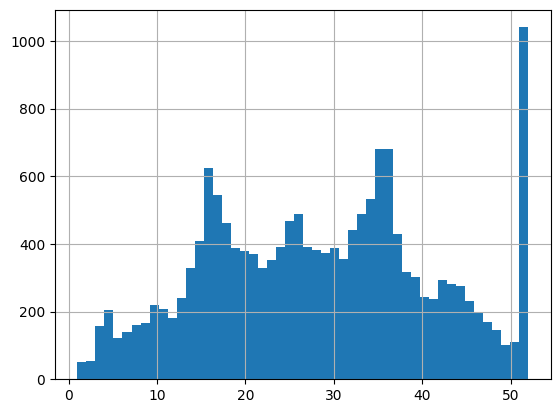

In [58]:
housing["housing_median_age"].hist(bins=50)

### 5. 当特征具有多峰分布，另一种方法时为每个模式（至少是主要模式）添加一个特征
* 例如在housing中为模式（峰）添加一个特征，表示房屋年龄中位数与该特定模式之间的相似性。
* 相似性度量通常使用径向基函数(Radial Basis Function, RBF)计算——任何一个仅取决于输入值和固定点之间距离的函数。
* 最常用的RBF是高斯RBF，其输出值随着输入值原理固定点而呈指数衰减。
---
* 例如，房屋年龄x与35之间的高斯RBF相似性由$exp(-γ(x-35))$给出。超参γ决定了当x远离35时相似性度量衰减的速度
* 使用scikit-learn的rbf_kernel()函数

In [59]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1) # 返回的是相似性度量值，ndarray

In [60]:
age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]])

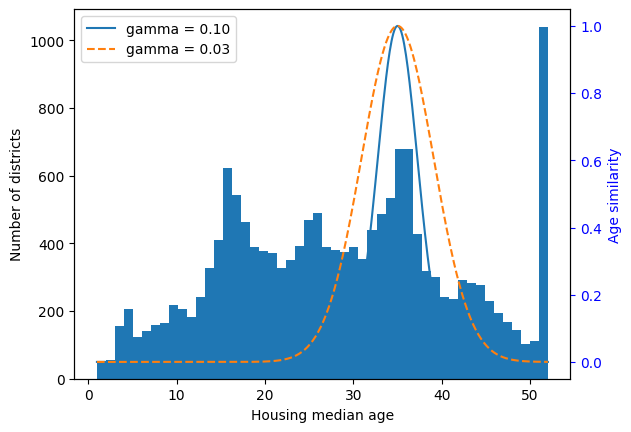

In [61]:
# np.linspace(start, stop, num)：在区间 [start, stop] 上生成 num 个等间距点；.reshape(-1, 1)：把一维数组变成形状为 (500, 1) 的二维数组
# rbf_kernel 要求输入是 (样本数, 特征数) 的二维结构
ages = np.linspace(housing["housing_median_age"].min(),
                    housing["housing_median_age"].max(),
                    500).reshape(-1, 1)

gamma1 = 0.1 # gamma 越大 → 相似度随距离下降越快
gamma2 = 0.03

# 计算“与 35 岁的相似度曲线”
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

# fig：创建一个图形；ax1：创建第一个坐标轴
fig, ax1 = plt.subplots()

# 在左 y 轴画“年龄分布直方图”
ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

# 创建共享 x 轴的第二个 y 轴
ax2 = ax1.twinx()

# 在右 y 轴画 RBF 相似度曲线
color = "blue"
ax2.plot(ages, rbf1, label="gamma = 0.10")
ax2.plot(ages, rbf2, label="gamma = 0.03", linestyle="--")

# 设置右 y 轴样式与含义
ax2.tick_params(axis="y", colors=color) # 指定右 y 轴刻度颜色
ax2.set_ylabel("Age similarity", color=color) # 标注右 y 轴含义：年龄相似度

# 显示图例（区分两条 gamma 曲线）
plt.legend(loc="upper left")
plt.show()


### 8.3.5. 对目标值也应用转换
* 使用Scikit-Learn的转换器(`inverse_transform()`和`TransformedTargetRegressor()`)

假如目标分布有一条重尾，需要使用对数替换目标值（转换），那么结果并不是所要预测的结果，需要计算模型预测的指数（逆转换）`Scikit-Learn`的`inverse_transform()`方法可方便计算逆转换的结果

In [62]:
housing_label

13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
           ...   
14207    500001.0
13105     88800.0
19301    148800.0
19121    500001.0
19888    233300.0
Name: median_house_value, Length: 16512, dtype: float64

实验：说明[[]]和[]的区别和作用

In [63]:
print(type(housing["median_income"]))
# 一维对象（Series，形状 (n_samples,)）
# 单中括号：取“列向量”（Series）
print(housing["median_income"].shape)

<class 'pandas.core.series.Series'>
(16512,)


In [64]:
print(type(housing[["median_income"]]))
# 二维对象（DataFrame，形状 (n_samples, 1)）
# 双中括号：取“表格的一列”（DataFrame）
# sklearn 对 X 的统一约定是：X.shape == (样本数, 特征数)，所以需要把“一个特征”明确表示成“n_samples × 1 的特征矩阵”
print(housing[["median_income"]].shape)

<class 'pandas.core.frame.DataFrame'>
(16512, 1)


In [65]:
print(housing[["median_income", "total_rooms"]].shape)

(16512, 2)


In [66]:
# 步骤说明：
#   1. 使用StandardScaler缩放标签
#   2. 训练一个简单的线性回归模型
#   3. 对新数据进行预测
#   4. 使用经过训练的缩放器的inverse_transform()方法转回原始尺度
# 注意： 由于StandardScaler需要2D输入，故需将标签从Pandas Series转换为DataFrame
# 仅在单个原始输入特征（收入中位数）训练模型
from sklearn.linear_model import LinearRegression

# 使用StandardScaler缩放标签
target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_label.to_frame())

# 训练一个简单的线性回归模型
model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)

some_new_data = housing[["median_income"]].iloc[:5] # 假设新数据

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

predictions

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

In [67]:
# 更简单的方法是使用TransformedTargetRegressor
# 只需构造该方法，给它回归模型和标签转换器，然后使用未缩放标签将它拟合到训练集上。
# 它自动使用转换器缩放标签并在缩放后的标签上训练回归模型，就像使用StandardScaler那样。
# 当进行预测时，它会自动调用回归模型的predict()方法并使用缩放器的inverse_transform()方法来产生预测
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_label)
predictions = model.predict(some_new_data)

predictions

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

下面是一张**系统、对照清晰、可当速查表使用**的总结，覆盖 pandas 中**最常见、也最容易混淆**的
`[] / [[]] / loc / iloc` 用法。

你可以把这张表当作**“看到代码就能反推出结果形状与类型”的参考表**。

---

# pandas 索引与选择方式对照表

## 一、最基础：`[]`（列选择为主）

| 写法                     | 作用        | 返回类型        | 形状               | 典型用途             |
| ---------------------- | --------- | ----------- | ---------------- | ---------------- |
| `df["col"]`            | 选择单列      | `Series`    | `(n,)`           | 快速取一列            |
| `df[["col"]]`          | 选择单列（表形式） | `DataFrame` | `(n, 1)`         | 作为 sklearn 的 `X` |
| `df[["col1", "col2"]]` | 选择多列      | `DataFrame` | `(n, 2)`         | 多特征建模            |
| `df[cols]`（cols 是列表）   | 选择多列      | `DataFrame` | `(n, len(cols))` | 动态列选择            |

❌ **错误写法**

```python
df[["col1"], ["col2"]]   # 错误：这是 tuple，不是列列表
```

---

## 二、`loc`：**按“标签”索引（推荐，最安全）**

> `loc[row_indexer, col_indexer]`

### 1️⃣ 行选择

| 写法                  | 含义                   |
| ------------------- | -------------------- |
| `df.loc[5]`         | 索引标签为 5 的那一行         |
| `df.loc[5:10]`      | 标签 5 到 10（**包含 10**） |
| `df.loc[[1, 3, 7]]` | 多个指定行                |
| `df.loc[mask]`      | 布尔条件选行               |

---

### 2️⃣ 行 + 列选择（最常用）

| 写法                               | 返回类型        | 说明       |
| -------------------------------- | ----------- | -------- |
| `df.loc[:, "col"]`               | `Series`    | 所有行 + 单列 |
| `df.loc[:, ["col"]]`             | `DataFrame` | 所有行 + 单列 |
| `df.loc[:, ["col1", "col2"]]`    | `DataFrame` | 所有行 + 多列 |
| `df.loc[5:10, ["col1", "col2"]]` | `DataFrame` | 行列同时筛选   |

📌 **记忆点**

> `loc` 是 **“名字驱动”**：
> 行用索引标签，列用列名

---

## 三、`iloc`：**按“位置”索引（0-based）**

> `iloc[row_pos, col_pos]`

### 1️⃣ 行选择

| 写法                   | 含义                    |
| -------------------- | --------------------- |
| `df.iloc[0]`         | 第 1 行                 |
| `df.iloc[0:5]`       | 第 1 到第 5 行（**不包含 5**） |
| `df.iloc[[0, 2, 4]]` | 指定位置的行                |

---

### 2️⃣ 行 + 列选择

| 写法                   | 返回类型        | 说明          |
| -------------------- | ----------- | ----------- |
| `df.iloc[:, 0]`      | `Series`    | 所有行 + 第 1 列 |
| `df.iloc[:, [0]]`    | `DataFrame` | 所有行 + 第 1 列 |
| `df.iloc[:, [0, 2]]` | `DataFrame` | 所有行 + 多列    |
| `df.iloc[0:5, 1:3]`  | `DataFrame` | 行列按位置切      |

📌 **记忆点**

> `iloc` 是 **“位置驱动”**：
> 行列全部用整数位置

---

## 四、`Series` 的索引（补充）

当你已经是 `Series` 时：

```python
s = df["median_income"]
```

| 写法          | 含义         | 返回     |
| ----------- | ---------- | ------ |
| `s[5]`      | 索引标签为 5 的值 | 标量     |
| `s.iloc[5]` | 第 6 个元素    | 标量     |
| `s.loc[5]`  | 标签为 5 的元素  | 标量     |
| `s[5:10]`   | 切片         | Series |

---

## 五、最容易混淆的“关键对照点”（一定要记）

### 1️⃣ 单中括号 vs 双中括号

| 写法            | 本质           | sklearn 能用？ |
| ------------- | ------------ | ----------- |
| `df["col"]`   | 一维 Series    | ❌（1D）       |
| `df[["col"]]` | 二维 DataFrame | ✅（2D）       |

---

### 2️⃣ `loc` vs `iloc`

| 对比点      | `loc`  | `iloc` |
| -------- | ------ | ------ |
| 基于什么     | 标签     | 位置     |
| 切片是否包含右端 | ✅ 包含   | ❌ 不包含  |
| 是否推荐新手   | ✅ 强烈推荐 | ⚠️ 易越界 |

---

## 六、给你一个“心智模型”（非常重要）

你可以这样在脑中区分：

* `[]`：**快捷列选择**
* `loc`：**语义清晰、按名字选**
* `iloc`：**精确控制、按位置选**
* `[[...]]`：**“我明确要一个表，不是向量”**

---

## 七、一句话终极总结（请记住）

> **pandas 里“报错最多”的不是算法，而是“维度和索引方式选错”；
> 看清你要的是 Series 还是 DataFrame，就知道该用几个中括号。**

如果你愿意，下一步我可以帮你把这张表 **压缩成“sklearn 建模专用索引规范”**，只保留你在机器学习里真正会用到的 20%。


## 8.4. 定制转换器
需要编写自己的转换器来执行自定义转换、清晰操作或组合一些特定的属性等任务

* 举例：创建一个对数转换器并将其应用与population特征


---

# FunctionTransformer

## 一、方法功能

**FunctionTransformer** 的功能是：

> 将一个任意可调用对象（函数）包装成一个符合 scikit-learn Transformer 接口的对象，用于对输入 `X` 进行**无状态（stateless）的确定性变换**。

核心特征：

* 不从数据中学习任何参数
* 不依赖数据分布
* 仅在 `transform()` / `inverse_transform()` 中执行函数调用
* 可无缝用于 `Pipeline`、`ColumnTransformer`、交叉验证等

---

## 二、继承关系（决定其行为）

```python
class FunctionTransformer(TransformerMixin, BaseEstimator)
```

由此决定：

* 具备 `fit / transform / fit_transform` 接口
* 可被 sklearn 的模型选择、验证、组合工具识别
* 被视为 **Transformer 而非 Estimator**

---

## 三、主要参数（功能、意义、注意事项）

### 1️⃣ `func`

* **类型**：`callable` 或 `None`
* **功能**：正向变换函数，在 `transform()` 中调用
* **源码行为**：

  * 若为 `None`，使用恒等函数 `_identity`
  * 实际执行逻辑：`func(X, **kw_args)`
* **注意事项**：

  * sklearn 不校验函数正确性
  * 函数必须能处理传入的 `X`
  * 返回结果需与输入形状兼容

---

### 2️⃣ `inverse_func`

* **类型**：`callable` 或 `None`
* **功能**：反向变换函数，在 `inverse_transform()` 中调用
* **源码行为**：

  * 若为 `None`，使用恒等函数
* **注意事项**：

  * sklearn 不验证是否真为数学逆
  * 与 `check_inverse` 联合使用时可能触发警告

---

### 3️⃣ `validate`

* **类型**：`bool`
* **功能**：是否对输入 `X` 进行 sklearn 标准校验
* **源码行为**：

  * `True`：强制将 `X` 转为 2D ndarray / sparse matrix
  * `False`：直接透传 `X`
* **注意事项**：

  * `False` 时支持更灵活的输入（如 DataFrame、自定义对象）
  * `True` 时可能破坏原始数据结构

---

### 4️⃣ `accept_sparse`

* **类型**：`bool`
* **功能**：是否允许稀疏矩阵作为输入
* **生效条件**：

  * 仅在 `validate=True` 时生效
* **注意事项**：

  * 若 `func` 不支持稀疏矩阵，应设为 `False`

---

### 5️⃣ `check_inverse`

* **类型**：`bool`
* **功能**：在 `fit()` 阶段检查 `func` 与 `inverse_func` 是否近似互逆
* **源码行为**：

  * 抽样部分数据
  * 执行 `inverse_func(func(X))`
  * 使用数值近似判断
* **注意事项**：

  * 不满足时仅 **警告**，不报错
  * 仅支持数值型输入

---

### 6️⃣ `feature_names_out`

* **类型**：`callable`、`"one-to-one"` 或 `None`
* **功能**：定义 `get_feature_names_out()` 的输出规则
* **源码行为**：

  * `"one-to-one"`：输出特征名与输入一致
  * `callable`：由用户函数生成
* **注意事项**：

  * 仅在该参数非 `None` 时，`get_feature_names_out()` 才可用

---

### 7️⃣ `kw_args` / `inv_kw_args`

* **类型**：`dict` 或 `None`
* **功能**：为 `func` / `inverse_func` 传递关键字参数
* **源码行为**：

  * 在 `_transform()` 中以 `func(X, **kw_args)` 调用

---

## 四、输入与输出（源码约束）

### 输入 `X`

* 接受：

  * `numpy.ndarray`
  * `scipy.sparse`
  * `pandas.DataFrame`（当 `validate=False`）
* 形状：

  * 通常为 `(n_samples, n_features)`
  * sklearn 不强制解释维度含义

---

### 输出

* **类型**：

  * 默认：`numpy.ndarray`
  * 若 `set_output(transform="pandas")` 且 `func` 返回 DataFrame，可保持 DataFrame
* **形状**：

  * 与输入一致
* **特性**：

  * 不新增、不删除特征
  * 不重排样本

---

## 五、核心方法行为总结

### `fit(X, y=None)`

* 不学习参数
* 可选执行：

  * 输入校验（`validate=True`）
  * 正反变换一致性检查（`check_inverse=True`）
* 始终返回 `self`

---

### `transform(X)`

* 执行：`func(X, **kw_args)`
* 不依赖 `fit` 产生的状态
* 可根据 `set_output` 决定返回容器类型

---

### `inverse_transform(X)`

* 执行：`inverse_func(X, **inv_kw_args)`
* 仅当提供 `inverse_func` 时可用

---

## 六、重要设计与使用注意事项（源码层面）

1. **完全无状态**

   * `__sklearn_is_fitted__()` 永远返回 `True`
   * 不需要、也不依赖 `fit()`

2. **sklearn 不保证数学正确性**

   * 函数是否合法、是否互逆，责任在用户

3. **适合纯函数变换**

   * 不适合需要数据统计量的变换（如标准化、归一化）

4. **接口价值大于计算价值**

   * 核心作用是“接入 sklearn 生态”，而非计算本身

---

## 七、一句话结论（源码级）

> **FunctionTransformer 是一个“无状态的函数封装器”，其唯一职责是在不学习任何参数的前提下，将任意函数纳入 scikit-learn 的 Transformer 生命周期与接口体系。**


In [68]:
from sklearn.preprocessing import FunctionTransformer # FunctionTransformer：把“任意函数”包装成一个“符合 sklearn Transformer API 的对象”。

# FunctionTransformer 是“无状态”的 transformer。不学习任何参数
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp) # inverse_func参数可选，允许指定一个逆变换函数
log_pop = log_transformer.transform(housing[["population"]])


自定义转换函数可作为超参数作为附加参数。
* 例如：创建一个转换器来计算高斯RBF相似性度量

In [69]:
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

# 注意：RBF内核没有反函数，因为相对一个点的相同距离的点会有两个

* rbf_kernel()不会单独处理这些特征，如果向它传入具有两个特征的数组，它会测量2D距离（欧几里得）来测量相似性
* 例如：添加一个特征来测量每个地区与旧金山地区之间的地理相似性

In [70]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

sf_simil

array([[0.999927  ],
       [0.05258419],
       [0.94864161],
       ...,
       [0.00388525],
       [0.05038518],
       [0.99868067]])

* 自定义转换器也可以用于组合特征。
* 例如：计算输入特征0和1之间比率（即第一列与第二列的比率）的FunctionTransformer()

In [71]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

FunctionTransformer非常方便,但是如果你希望你的转换器是可训练的,可以在 fit()方法中学习一些参数并稍后在transform()方法中使用它们,你该怎么办? 为此,你需要编写一个自定义类。Scikit-Learn依赖鸭子类型,因此此类不必继承 自任何特定的基类。它只需要三个方法:fit()(必须返回self)、transform() 和fit_transform()。 你只需将TransformerMixin添加为基类即可以得到fit_transform():默认实现将只调 用fit(),然后调用transform()。如果将BaseEstimator添加为基类(避免在构造函 数中使用*args和**kwargs),你还将获得两个额外的方法:get_params()和set_params ()。这些对于自动超参数调整很有用

---

## 一、这段话在回答一个核心问题

> **如果你的特征变换不是“纯函数”，而是需要从数据中学习参数，该怎么办？**

前面你已经见过：

* `FunctionTransformer`
  → **不学习任何参数（无状态）**

但现实中很多变换是：

* 需要在训练数据上**估计参数**
* 然后在新数据上**复用这些参数**

这类变换就叫：**可训练（trainable）的转换器**。

---

## 二、scikit-learn 并不强制你继承“某个复杂父类”

这句话是关键背景：

> **Scikit-Learn 依赖“鸭子类型（duck typing）”**

### 什么是鸭子类型（通俗解释）

> “不看你是谁，只看你会不会做这几件事。”

在 sklearn 里，**一个对象是不是 Transformer，不是看它继承了谁，而是看：**

* 有没有 `fit()`
* 有没有 `transform()`

只要你“像一个 Transformer 那样工作”，
sklearn 就“把你当 Transformer 用”。

---

## 三、一个“可训练转换器”最少需要哪些方法？

### 1️⃣ `fit()`

* **作用**：
  从训练数据中 **学习/估计参数**
* **要求**：

  * 方法签名通常是 `fit(self, X, y=None)`
  * **必须返回 `self`**

👉 返回 `self` 是为了支持链式调用和 Pipeline。

---

### 2️⃣ `transform()`

* **作用**：
  使用 `fit()` 中学到的参数，对数据进行转换
* **注意**：

  * 不能在这里再“学习参数”
  * 只能“使用已经学到的东西”

---

### 3️⃣ `fit_transform()`

* **作用**：
  训练集专用的快捷方式
* **逻辑等价于**：

```python
self.fit(X)
return self.transform(X)
```

---

## 四、为什么“只需要”继承 `TransformerMixin`

原文这句你卡住了：

> “你只需将 TransformerMixin 添加为基类即可以得到 fit_transform()”

### 含义是：

* `TransformerMixin` **已经帮你写好了 `fit_transform()`**
* 你只需要自己实现：

  * `fit`
  * `transform`

### 换句话说

```text
你写 fit()
你写 transform()
sklearn 自动给你 fit_transform()
```

这就是 `TransformerMixin` 的唯一职责。

---

## 五、那 `BaseEstimator` 是干什么用的？

原文后半段在说另一件事：

> “如果将 BaseEstimator 添加为基类……你还将获得 get_params() 和 set_params()”

### 这两个方法是干什么的？

* `get_params()`
  → sklearn 用它来**读取超参数**
* `set_params()`
  → sklearn 用它来**修改超参数**

### 为什么重要？

因为这些方法是：

* `GridSearchCV`
* `RandomizedSearchCV`
* Pipeline 自动调参

**工作的基础**。

👉 **没有 `BaseEstimator`，你的自定义类就无法被 sklearn 自动调参。**

---

## 六、为什么强调“不要在 `__init__` 里用 `*args` / `**kwargs`”

这是一个**非常工程化但很关键的点**。

### sklearn 的规则是：

> **构造函数里的参数 = 超参数**

`BaseEstimator` 会通过反射检查：

```python
__init__(self, param1=..., param2=...)
```

来知道：

* 有哪些参数
* 当前取值是什么

如果你写成：

```python
def __init__(self, *args, **kwargs):
    ...
```

👉 sklearn **无法知道你的超参数结构**
👉 自动调参、模型保存都会失效

---

## 七、把整段话翻译成“人话版”

> * `FunctionTransformer` 适合**不需要学习参数的纯函数变换**
> * 如果你的变换需要从数据中学习参数（比如均值、阈值、比例等），你就要写一个**自定义转换器类**
> * sklearn 不要求你继承复杂的父类，只要你实现 `fit()` 和 `transform()` 就行
> * 继承 `TransformerMixin` 可以免费获得 `fit_transform()`
> * 继承 `BaseEstimator` 可以免费获得 `get_params()` 和 `set_params()`，从而支持自动超参数搜索
> * 构造函数里必须显式写参数，不能用 `*args / **kwargs`

---

## 八、一句话总结（最重要）

> **当你的特征变换需要“从训练数据中学规则”时，就不能再用 FunctionTransformer，而应该写一个自定义 Transformer；继承 TransformerMixin 和 BaseEstimator，是让它真正融入 scikit-learn 生态的关键。**



写一个与StandardScaler相似的自定义转换器

In [72]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted # 验证工具
# check_is_fitted：检查模型是否已经调用过 fit()

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True): # 不能是 *args 或 *kwargs，BaseEstimator 需要通过 __init__ 的显式参数来识别“有哪些超参数”
        self.with_mean = with_mean # 是否在标准化前减去均值

    def fit(self, X, y=None):
        X = check_array(X)
        self.mean_ = X.mean(axis=0) # 计算每个特征的均值（按列计算）
        self.scale_ = X.std(axis=0) # 计算每个特征的标准差
        self.n_features_in_ = X.shape[1]
        return self # 支持链式调用

    def transform(self, X):
        check_is_fitted(self) # 确保已经执行过 fit()
        X = check_array(X) # 再次保证输入合法（新数据也要检查）
        assert self.n_features_in_ == X.shape[1] # 确保新数据特征数与训练时一致
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

注意：
* `sklearn.utils.validation`包中包含了可以用来验证输入的函数，生产环境中是很重要的
* `Scikit-Learn`流水线要求`fit()`方法中设置两个参数X和y，所以即使不使用y，也要把y设置为None
* 所有`Scikit-Learn`估计器都要在`fit()`方法中设置`n_feature_in_`，确保传递给`transform()`或`predict()`的数据具有这个数量的特征
* `fit()`方法必须返回self
* 所有估计器在传递DataFrame时都应在`fit()`方法中设置`feature_name_in_`
* 所有的转换器都应提供一个`get_feature_names_out()`方法(经过当前转换器（或整个 Pipeline）处理之后，输出的每一列特征“叫什么名字”。)，以及`inverse_transform()`方法，当它们的转换可以被逆转时

自定义转换器经常在其实现中使用其他估计器
* 例如：使用KMeans的自定义转换器在`fit()`方法中识别出训练数据中的主要集群，然后在Transform()方法中使用`rkb_kernel()`来测量每个样本与每个集群中心的相似程度

In [77]:
# 这个自定义转换器先用 KMeans 在训练数据上学习“聚类中心”，然后把每个样本转换为“它与各个聚类中心的相似度特征”。
# 输入：原始特征 X
# 输出：n_clusters 个新特征
#   每一列 = “与某一个聚类中心的相似度”
from sklearn.cluster import KMeans # 导入 KMeans 聚类模型, 它是一个完整的 sklearn 估计器（有 fit()、内部参数等）
from sklearn.utils.validation import validate_data, check_is_fitted

class ClusterSimilarity(TransformerMixin, BaseEstimator):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=42):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    # def fit(self, X, y=None): # 如果想要过check_estimator()，必须要将sample_weight删去
    def fit(self, X, y=None, sample_weight=None):
        # 验证输入 + 自动设置 n_features_in_
        X = validate_data(self, X)
        # 创建一个内部估计器
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state) # 实例化一个 KMeans 对象
        self.kmeans_.fit(X, sample_weight=sample_weight) # ClusterSimilarity.fit() 并不直接学习参数,它委托 KMeans 去学习, KMeans 在这里学习到的是：cluster_centers_;如果想要过check_estimator()，必须要将sample_weight删去
        return self

    def transform(self, X):
        # 确保已经 fit
        check_is_fitted(self)
        # 检查特征数一致性（reset=False 非常关键）
        X = validate_data(self, X, reset=False)
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None): # get_feature_name_out()：输出特征名
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

可通过将实例传递给`sklearn.utils.estimator_checks`包中的`check_estimator()`来检查你的自定义估算器是否遵循Scikit-Learn的API

In [76]:
from sklearn.utils.estimator_checks import check_estimator

check_estimator(
    ClusterSimilarity(n_clusters=3, gamma=1.0, random_state=0)
)

[{'estimator': ClusterSimilarity(n_clusters=3, random_state=0),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': ClusterSimilarity(n_clusters=3, random_state=0),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': ClusterSimilarity(n_clusters=3, random_state=0),
  'check_name': 'check_estimator_tags_renamed',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': ClusterSimilarity(n_clusters=3, random_state=0),
  'check_name': 'check_valid_tag_types',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': ClusterSim

* k均值是一种聚类算法（KMeans），用于数据中定位集群。
* 它的搜索数量是由`n_clusters`超参数控制的。
* 训练后，集群中心可通过`cluster_centers_`属性获得。
* KMeans的`fit()`方法支持可选参数`sample_weight`，它允许用户指定样本的相对权重。
* k均值是一种随机算法，意味着它依赖于随机性来定位集群，所以如果你想要可重现的结果，必须设置`random_state`参数

使用自定义转换器

In [78]:
# 创建一个ClusterSimilarity转换器，将集群数设置为10
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
# 用训练集中每个地区的经纬度调用fit_transform()，用每个地区的房价中位数加权。
# Transformer使用k均值定位集群，然后测量每个地区与所有10个集群中心之间的高斯RBF相似性。
# 结果是一个矩阵，每个地区一行，每个集群一列
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]],
                                           sample_weight=housing_label)

# 查看前三行，四舍五入到小数点后两位
similarities[:3].round(2)


array([[0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.13, 0.55, 0.  , 0.56],
       [0.64, 0.  , 0.11, 0.04, 0.  , 0.  , 0.  , 0.  , 0.99, 0.  ],
       [0.  , 0.65, 0.  , 0.  , 0.01, 0.  , 0.49, 0.59, 0.  , 0.28]])

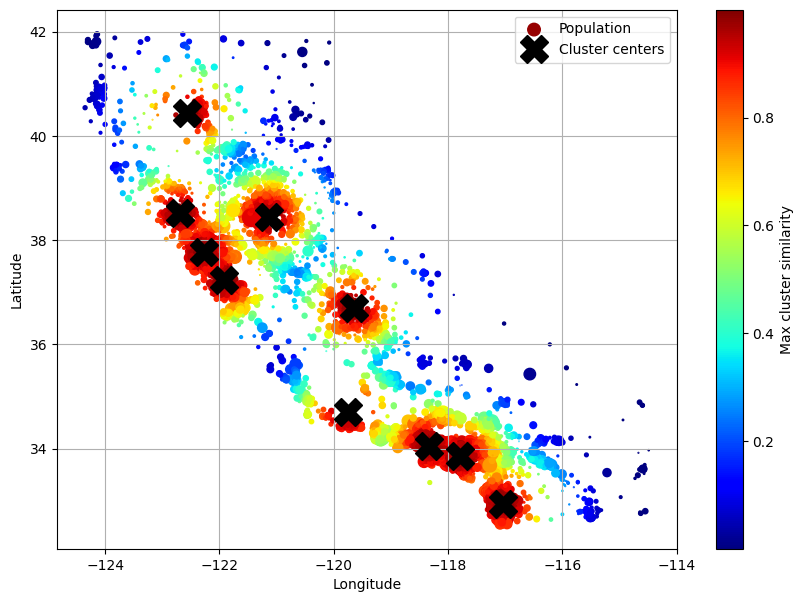

In [79]:
# extra code – this cell generates Figure 2–19
plt.style.use("default")

# 创建一个新的 DataFrame housing_renamed，将原始 housing 中部分列名改成更适合展示和作图的名称
# rename()：columns={旧名: 新名}：只改列名，不影响数据，原 DataFrame 不变，返回一个新对象
housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
# 计算每个样本的“最大聚类相似度”
# .max(axis=1)：对 每一行 取最大值 即：这个地区 最像哪一个聚类中心
# 这是一个 连续数值特征，后面用来着色。
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

# 绘制地理散点图
housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True, # kind="scatter"：散点图， grid=True：显示网格线
                     s=housing_renamed["Population"] / 100, label="Population", # 点的大小：人口规模
                     c="Max cluster similarity", # c：颜色映射字段
                     cmap="jet", colorbar=True, # cmap="jet"：颜色从蓝 → 绿 → 黄 → 红；colorbar=True：右侧显示颜色条
                     legend=True, sharex=False, figsize=(10, 7)) # legend=True 显示图例； sharex=False：不共享 x 轴（避免某些 Pandas 子图问题）

# 在地图上标出聚类中心
# cluster_centers_ 形状是：(n_clusters, 2) 约定：第 0 列：Latitude；第 1 列：Longitude，所以需要交换顺序
# x = Longitude = [:, 1];y = Latitude  = [:, 0]
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20, # linestyle=""：不画线；marker="X"：用 X 标记； markersize=20：非常醒目
         label="Cluster centers") # label="Cluster centers"：图例名称
plt.legend(loc="upper right") # 手动放置图例
plt.show()

### 8.5. 转换流水线(Pipeline)


设计一个小的pipeline，用于数值属性的估算与输入特征的缩放

In [80]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])


pipeline构造函数采用定义一系列步骤的名称/估计器对（二元组）列表。名称是随意的，只要它们是唯一且不包含双下划线(__)

估计器除了最后一个必须都是转换器，即必须有一个`fit_transform()方法`，最后一个可以是任何东西：转换器、预测器或其他类型的估计器

如果不想给转换器命名，则可以使用`make_pipeline()`函数代替。
* 它以转换器作为位置参数，并使用转换器类的名称创建流水线，小写且不带下划线（例如"simpleimputer"）

In [81]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

如果多个转换器名称相同，则可在名称后加一个索引（如"foo-1"、"foo-2"等）

 * 当调用pipeline的`fit()`方法时，它会在所有转换器上依次调用`fit_transform()`，将每次调用的输出作为参数传递给下一次调用，直到它到达最终的估计器，它**只调用`fit()`方法**
* pipeline公开了与最终估计器相同的方法。
    * 如果最后一个估计器是一个转换器(如`StandardScaler`)，则pipeline也是一个转换器
    * 如果调用pipeline的`transform()`方法，它将顺序地将所有转换应用与数据
    * 如果最后一个估计器预测器，则pipeline有一个`predict()`方法，而不是`transform()`方法。调用它会按顺序将所有转换应用于数据并将结果传递给预测器的`predict()`方法

调用pipeline的`fit_transform()`方法并查看前两行的输出，四舍五入到小数点后两位

In [82]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

如果想将其恢复为DataFrame,可使用pipeline的`get_feature_names_out()`方法

In [84]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index
)
df_housing_num_prepared

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365
...,...,...,...,...,...,...,...,...
14207,0.586397,-0.833359,0.987087,-0.184147,0.140152,-0.445315,0.060101,0.444041
13105,0.131525,0.319822,-0.443146,0.139847,0.128298,-0.005950,0.083608,-0.685630
19301,1.256209,-1.428701,-1.237721,0.586026,0.562134,1.268299,0.679135,0.101049
19121,0.586397,-0.739605,0.669257,0.522417,0.794461,0.273563,0.882868,0.145396


pipeline支持索引

In [85]:
num_pipeline[1] # 查看第二个估计器

StandardScaler()

In [86]:
num_pipeline[:-1] # 返回一个pipeline对象，其包含除最后一个估计器外的所有估计器

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median'))])

访问估计器

In [87]:
num_pipeline.steps # 返回 名称/估计器 对列表

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [88]:
num_pipeline.named_steps # 返回字典，将名称映射到估计器上

{'simpleimputer': SimpleImputer(strategy='median'),
 'standardscaler': StandardScaler()}

In [89]:
num_pipeline["simpleimputer"] # 通过名称访问估计器，返回对应估计器

SimpleImputer(strategy='median')

In [90]:
type(num_pipeline)

sklearn.pipeline.Pipeline

---

## 一、Pipeline 是什么

**Pipeline 是把一连串数据处理步骤和模型，按顺序“打包”为一个整体的工具。**

形式上可以理解为：

```
原始数据
  ↓
转换器1（如缺失值处理）
  ↓
转换器2（如标准化）
  ↓
转换器3（如特征工程）
  ↓
模型（回归 / 分类）
```

在 scikit-learn 中，这整个流程被封装成 **一个 estimator**。

---

## 二、Pipeline 解决了什么问题（为什么要用）

### 1️⃣ 防止数据泄漏（最重要）

**错误做法（手写流程，极易泄漏）：**

```python
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
```

一旦你写错顺序或在全数据上 `fit()`，就会发生**信息泄漏**。

**Pipeline 的本质保证：**

> **所有 `fit()` 只发生在训练数据上**

---

### 2️⃣ 让“训练 + 预测”变成一行代码

```python
pipeline.fit(X_train, y_train)
pipeline.predict(X_test)
```

你不再关心：

* 哪一步先做
* 哪一步需要 transform
* 哪一步需要 fit

---

### 3️⃣ 自动支持交叉验证和网格搜索

Pipeline 是一个**合法的 estimator**，可以直接用于：

* `cross_val_score`
* `GridSearchCV`
* `RandomizedSearchCV`

这是手写流程 **无法安全做到的**。

---

## 三、Pipeline 的基本结构

### 1️⃣ 构造方式

```python
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("step1", transformer1),
    ("step2", transformer2),
    ("model", estimator)
])
```

**核心规则：**

* 前面 **全部是转换器**
* 最后 **必须是估计器**

---

### 2️⃣ 每一步必须满足什么条件？

| 位置   | 要求                          |
| ---- | --------------------------- |
| 中间步骤 | 必须有 `fit()` + `transform()` |
| 最后一步 | 必须有 `fit()`，通常有 `predict()` |
| 每一步  | 接收 X，输出 X                   |

---

## 四、Pipeline 在内部是如何工作的？

### `pipeline.fit(X, y)` 的真实流程

```text
step1.fit(X)
X1 = step1.transform(X)

step2.fit(X1)
X2 = step2.transform(X1)

model.fit(X2, y)
```

### `pipeline.predict(X)` 的真实流程

```text
X1 = step1.transform(X)
X2 = step2.transform(X1)

y_pred = model.predict(X2)
```

⚠️ **注意：预测阶段不会再调用 fit**

---

## 五、Pipeline 的核心组件

### 1️⃣ 转换器（Transformer）

* `StandardScaler`
* `SimpleImputer`
* `OneHotEncoder`
* 自定义 Transformer

要求：

```text
fit()
transform()
```

---

### 2️⃣ 估计器（Estimator）

* `LinearRegression`
* `LogisticRegression`
* `RandomForestClassifier`

要求：

```text
fit()
predict() / score()
```

---

## 六、Pipeline 和 GridSearchCV 的配合（重点）

### 参数命名规则（非常重要）

```python
"步骤名__参数名"
```

### 示例

```python
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "scaler__with_mean": [True, False],
    "model__alpha": [0.1, 1.0, 10.0]
}
```

Pipeline 自动完成：

* 每一组参数
* 每一次交叉验证
* 严格防止数据泄漏

---

## 七、Pipeline 常见误区（你一定会踩）

### ❌ 误区 1：在 Pipeline 外先做 transform

```python
X_scaled = scaler.fit_transform(X)
pipeline.fit(X_scaled, y)  # ❌
```

**正确做法：**

```python
pipeline.fit(X, y)
```

---

### ❌ 误区 2：最后一步放 Transformer

```python
Pipeline([
    ("scaler", StandardScaler())
])  # ❌ 没有模型
```

Pipeline 的**最后一步必须是 estimator**（或 `passthrough`）。

---

### ❌ 误区 3：手动调用中间步骤

```python
pipeline["scaler"].fit(X)  # ❌
```

Pipeline 的设计目标是：

> **你不再单独操作步骤**

---

## 八、Pipeline 的一句话心智模型（非常重要）

> **Pipeline = 一个“会自动按顺序执行的、不会泄漏数据的超级模型”**

你只需要记住三件事：

1. 数据从上往下流
2. fit 只发生在训练数据
3. 最终你只和 pipeline 交互

---

## 九、你现在这个阶段最该掌握的 Pipeline 用法

```python
Pipeline([
    ("preprocess", transformer),
    ("model", estimator)
])
```

当你真正理解了 Pipeline：

* 自定义 Transformer 的意义
* `check_estimator()` 的价值
* `ColumnTransformer` 的必要性
  都会自然“连起来”。

---

按列分流处理数据的转换器`ColumnTransformer`
* 使用`ColumnTransformer`将`num_pipeline`应用于数值属性，将`cat_pipeline`应用于分类属性

In [91]:
from sklearn.compose import ColumnTransformer # 导入 ColumnTransformer 类

# 定义数字和类别列名称的列表
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"]

cat_attribs = ["ocean_proximity"]

# 为分类属性构造一个简单的流水线
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# ColumnTransformer 构造函数需要一个三元组的列表，每个包含一个名称（必须是唯一且不包含双划线）、一个转换器以及一个转换器应该应用到的列的名称(或索引)列表
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

---

## 一、ColumnTransformer 是什么（一句话）

**ColumnTransformer 是一个“按列分流处理数据”的转换器。**

> 不同的列 → 用不同的预处理方法 → 再把结果拼接起来

---

## 二、为什么需要 ColumnTransformer？

在真实数据中，**不同列的性质完全不同**：

| 列类型       | 示例                  | 合适的处理方式         |
| --------- | ------------------- | --------------- |
| 数值型       | income, age         | 标准化、缺失值填补       |
| 分类型       | ocean_proximity     | OneHotEncoder   |
| 比例 / 派生特征 | rooms_per_household | 自定义 Transformer |
| 无用列       | id                  | 直接丢弃            |

**单个 Transformer 做不到“按列区分处理”**，于是就需要 ColumnTransformer。

---

## 三、ColumnTransformer 的核心思想（非常重要）

> **“先按列切分 → 各自 transform → 横向拼接”**

结构示意：

```
原始 DataFrame
 ├─ 数值列 ─→ 数值流水线 ─┐
 ├─ 类别列 ─→ 编码流水线 ─┼─→ 拼接 → 新特征矩阵
 └─ 其他列 ─→ 丢弃 / 保留 ─┘
```

---

## 四、基本用法（标准模板）

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
```

```python
preprocess = ColumnTransformer([
    ("num", StandardScaler(), ["median_income", "housing_median_age"]),
    ("cat", OneHotEncoder(), ["ocean_proximity"])
])
```

### 结构解释

```python
ColumnTransformer([
    (名字, transformer, 列选择)
])
```

* **名字**：给这一路处理起名（用于调参）
* **transformer**：任何 sklearn 转换器 / Pipeline
* **列选择**：

  * 列名列表（推荐）
  * 列索引
  * callable

---

## 五、ColumnTransformer 本身是一个 Transformer

这点非常关键：

```python
preprocess.fit(X_train)
X_new = preprocess.transform(X_test)
```

所以它**可以直接放进 Pipeline**：

```python
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
```

---

## 六、内部是怎么工作的？

### `fit(X)`

对每个子 transformer：

1. 从 X 中取出对应的列
2. 对这些列单独 `fit()`
3. 记住输出特征结构

---

### `transform(X)`

1. 按列切分 X
2. 每一块调用各自的 `transform()`
3. **按列横向拼接（hstack）**

---

## 七、关键参数（你必须掌握）

### 1️⃣ `remainder`

```python
ColumnTransformer(..., remainder="drop")   # 默认
ColumnTransformer(..., remainder="passthrough")
```

| 值               | 含义        |
| --------------- | --------- |
| `"drop"`        | 未指定的列直接丢弃 |
| `"passthrough"` | 未指定的列原样保留 |

⚠️ 注意：`passthrough` 的列会**排在最后**

---

### 2️⃣ `verbose_feature_names_out`

```python
verbose_feature_names_out=True
```

生成更清晰的特征名，例如：

```
num__median_income
cat__ocean_proximity_INLAND
```

---

### 3️⃣ `n_jobs`

```python
n_jobs=-1
```

对不同列组并行处理（大数据时有用）。

---

## 八、ColumnTransformer + Pipeline = 标准工业写法

这是你以后**最常用、最安全、最推荐**的结构：

```python
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

full_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
```

你现在看到的**所有 sklearn 官方示例，几乎都长这样**。

---

## 九、ColumnTransformer 中可以放什么？

✅ 合法的：

* StandardScaler
* OneHotEncoder
* Pipeline
* FunctionTransformer
* 自定义 Transformer（你刚刚写过的那种）

❌ 不合法的：

* 没有 transform() 的模型
* 返回 y 的 estimator

---

## 十、你这个阶段最容易犯的错误

### ❌ 错误 1：忘记最后还要 Pipeline

```python
preprocess.fit_transform(X)
model.fit(X_new, y)  # ❌ 易泄漏
```

正确做法：

```python
pipeline.fit(X, y)
```

---

### ❌ 错误 2：列名写错 / 列不存在

ColumnTransformer **不会静默忽略**，会直接报错。

---

### ❌ 错误 3：不知道输出顺序

输出特征顺序是：

```
按照 ColumnTransformer 中定义的顺序
```

不是原始 DataFrame 的顺序。

---

## 十一、一句话总结（记住这句）

> **Pipeline 解决“步骤顺序问题”，
> ColumnTransformer 解决“列分治问题”。**

二者结合，才是 sklearn 的完整数据建模范式。

---

* 由于列出所有的列名不方便，Scikit-Learn提供一个`make_colunm_selectore()`函数，它返回一个选择器函数，可使用它自动选择给定类型的所有特征，如数值或类别。可将该选择器函数传递给`ColumnTransformer`，而不是列名或索引
* 如果不关心转换器的命名，可以使用`make_column_transformer()`，它会为你选择名称，像`make_pipeline()`那样，自动命名为`pipeline-1`和`pipeline-2`

In [92]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

将`ColumnTransformer`应用于房屋数据

In [93]:
housing_prepared = preprocessing.fit_transform(housing)

In [94]:
housing_prepared

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.        ,
         0.        ,  0.        ],
       [-1.2030985 ,  1.27611874,  0.35142777, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.        ,
         0.        ,  0.        ],
       [-1.41803793,  0.94797769,  1.22545939, ...,  0.        ,
         0.        ,  1.        ]])

In [95]:
# 还原回DataFrame
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index
)

housing_prepared_fr


,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,0.0,1.0,0.0,0.0,0.0
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,0.0,1.0,0.0,0.0,0.0
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14207,0.586397,-0.833359,0.987087,-0.184147,0.140152,-0.445315,0.060101,0.444041,1.0,0.0,0.0,0.0,0.0
13105,0.131525,0.319822,-0.443146,0.139847,0.128298,-0.005950,0.083608,-0.685630,0.0,1.0,0.0,0.0,0.0
19301,1.256209,-1.428701,-1.237721,0.586026,0.562134,1.268299,0.679135,0.101049,0.0,0.0,0.0,0.0,1.0
19121,0.586397,-0.739605,0.669257,0.522417,0.794461,0.273563,0.882868,0.145396,1.0,0.0,0.0,0.0,0.0


#### 回顾pipeline将做什么以及为什么做

1. 数字特征中的缺失值将通过用中位数替换它们来估算，因为大多数的ML算法不期望缺失值。在分类特征中，缺失值将被最常见的类别替换。
2. 类别特征将被独热编码(OneHotEncoder)，因为大多数ML算法只接受数字输入。
3. 计算并添加一些比率特征：如bedrooms_ratio、rooms_per_house和people_per_house。希望这些能更好地与房价中位数相关联，从而帮助ML模型。
4. 还添加了一些集群相似性特征。这些可能比纬度和经度对模型更有用。
5. 长尾特征被它们的对数取代，因为大多数模型更喜欢具有大致均匀分布或高斯分布特征。
6. 所有数值特征都将被标准化，因为大多数ML算法更喜欢所有特征具有大致相同的尺度。

构建所有这些操作：

In [96]:
# 自定义比率特征，用于bedrooms_ratio、rooms_per_house和people_per_house
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

# 给 FunctionTransformer 输出的特征命名
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

# 用于“比率特征”的小流水线：
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"), # 补缺失值
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

# 对数变换流水线（解决长尾分布）
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"), # 中位数填补
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

# 聚类相似性特征
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

# 数值流水线
# 凡是没有被前面明确指定处理方式的数值列统一：补缺失 + 标准化
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# ColumnTransformer：核心调度器
preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
    remainder=default_num_pipeline) # 只有一列还未被处理：housing_meidan_age


运行此`ColumnTransformer`会执行所有转换并输出具有24个特征的Numpy数组

In [97]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,<1H OCEAN
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,INLAND
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,NEAR OCEAN
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,<1H OCEAN


In [98]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared

array([[ 1.84662439, -0.86602737, -0.33020372, ...,  1.        ,
         0.        ,  1.86111875],
       [-0.5081207 ,  0.0245495 , -0.25361631, ...,  0.        ,
         0.        ,  0.90762971],
       [-0.20215476, -0.04119332, -0.05104091, ...,  0.        ,
         0.        ,  0.35142777],
       ...,
       [-0.24249175, -0.10998748,  0.15854151, ...,  0.        ,
         1.        , -1.23772062],
       [ 0.25977479, -0.36093745, -0.21033248, ...,  0.        ,
         0.        ,  0.66925745],
       [ 3.61270996, -1.32397227,  0.04958379, ...,  0.        ,
         1.        ,  1.22545939]])

In [99]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [100]:
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index
)
housing_prepared_fr

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,...,geo__Cluster 6 similarity,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
13096,1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,4.581829e-01,1.241847e-14,...,8.489216e-04,9.770322e-01,2.382191e-08,3.819126e-18,0.0,0.0,0.0,1.0,0.0,1.861119
14973,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,6.511495e-10,9.579596e-01,...,5.614049e-27,1.260964e-13,1.103491e-01,3.547610e-01,1.0,0.0,0.0,0.0,0.0,0.907630
3785,-0.202155,-0.041193,-0.051041,-0.925266,-0.859927,-0.941997,-0.913030,-0.756981,3.432506e-01,4.261141e-15,...,5.641131e-03,7.303265e-01,2.508224e-08,2.669659e-18,0.0,1.0,0.0,0.0,0.0,0.351428
14689,-0.149006,-0.034858,-0.141475,0.952773,0.943475,0.670700,0.925373,-0.912253,2.244844e-15,2.704823e-01,...,5.913326e-35,5.201263e-20,1.712982e-03,8.874598e-01,0.0,1.0,0.0,0.0,0.0,-0.919891
20507,0.963208,-0.666554,-0.306148,1.437622,1.003590,0.719093,1.481464,0.034537,1.090228e-11,9.422206e-01,...,5.421817e-30,1.048030e-15,2.568824e-02,5.279506e-01,0.0,0.0,0.0,0.0,1.0,0.589800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14207,0.804368,-0.452111,-0.269780,0.465581,0.109720,-0.247054,0.379471,0.648953,1.115293e-10,9.505920e-01,...,1.878046e-28,1.651285e-14,4.776856e-02,3.463930e-01,1.0,0.0,0.0,0.0,0.0,0.987087
13105,-0.192328,0.036792,-0.073741,0.454022,0.477277,0.314542,0.402773,-0.637675,1.409886e-03,1.430917e-03,...,7.663746e-14,9.538119e-06,4.530237e-01,9.507766e-05,0.0,1.0,0.0,0.0,0.0,-0.443146
19301,-0.242492,-0.109987,0.158542,0.824206,0.859552,1.243381,0.889897,0.333540,8.098794e-20,3.501819e-02,...,1.715187e-42,5.158970e-25,5.966953e-06,1.346576e-01,0.0,0.0,0.0,0.0,1.0,-1.237721
19121,0.259775,-0.360937,-0.210332,0.987851,0.811293,0.579462,1.023329,0.377051,4.385614e-10,9.667073e-01,...,2.464809e-27,8.018690e-14,8.956217e-02,3.478114e-01,1.0,0.0,0.0,0.0,0.0,0.669257


In [101]:
housing_prepared_fr.shape

(16512, 24)

## 9. 选择和训练模型
1. 在训练集上训练和评估

## 9.1 在训练集上训练和评估
训练一个基本的线性回归模型

In [102]:
housing_label

13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
           ...   
14207    500001.0
13105     88800.0
19301    148800.0
19121    500001.0
19888    233300.0
Name: median_house_value, Length: 16512, dtype: float64

In [103]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_label)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000...
                                                   'households',
                                                   'median_income']),
                                                 ('geo', ClusterSimilarity(),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000016C1A0FC670>)])),
                ('linearregression', LinearRegression())])

查看前五个预测值并与标签进行比较

In [104]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(2)

array([245970.16, 372738.07, 135706.8 ,  91440.93, 330873.54])

In [105]:
housing_label.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

使用RMSE评估模型预测误差的大小

**警告**：在Scikit-Learn的最新版本中，必须使用`root_mean_squared_error(labels, predictions)`来计算均方根误差（RMSE），而非`mean_squared_error(labels, predictions, squared=False)`。下面的`try`/`except`代码块会尝试导入`root_mean_squared_error`，若导入失败则直接定义该函数。

In [110]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(housing_label, housing_predictions)
lin_rmse

68972.88910758478

In [ ]:
# from sklearn.metrics import mean_squared_error
#
# lin_rmse = mean_squared_error(housing_label, housing_predictions, squared=False) # 取消了squared参数
# lin_rmse

* 大多数地区的median_housing_values在12000~265000美元之间，因此68628美元的误差确实很大。
* 这是模型欠拟合训练数据的样例。可能意味着这些特征没有提供足够的信息来做出良好的预测，或者模型不够强大。
* 解决欠拟合的方法主要是选择更强大的模型，为训练算法提供更好的特征，或者减少对模型的约束（通常指减弱正则化）。
* 由于该模型未正则化，所以排除需要减少对模型的约束这个方法

首先想到的是选择一个更强大的模型，比如`DecisionTreeRegressor`（决策树，第六章讲到），它能在数据中发现复杂的非线性关系

In [113]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_label)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000...
                                                   'median_income']),
                                                 ('geo', ClusterSimilarity(),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000016C1A0FC670>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [116]:
# 在训练集上进行评估
housing_predictions = tree_reg.predict(housing)
print(housing_predictions[:5].round(2))
print(housing_label.iloc[:5].values)

[458300. 483800. 101700.  96100. 361800.]
[458300. 483800. 101700.  96100. 361800.]


In [119]:
tree_rmse = root_mean_squared_error(housing_label, housing_predictions)
tree_rmse

0.0

没有错误，有两种情况：
1. 模型对数据严重过拟合了
2. 模型完美无缺
---
在准备启动有信心的模型之前，不要接触测试集，因此需要使用一部分训练集进行训练，另一部分用于模型验证。

## 9.2 使用交叉验证及进行更好的评估

* 评估决策树模型的一种方法是使用`train_test_split()`函数将训练集拆分为较小的训练集和验证集，然后进行训练和预测，最后评估预测结果以评估决策树模型
* 一种替代方法是Scikit-Learn的`cross_val_score()`方法，即**K折交叉验证功能**，即将训练集随机拆分为10个不重叠的自己，这称为折叠，然后对决策树模型进行10次训练和评估，每次选用不同的折叠进行评估，并使用其他9次折叠进行训练。结果是一个包含10次评估分数的数组。

In [134]:
from sklearn.model_selection import cross_val_score

# 由于交叉验证功能是希望效用函数（越大越好）而不是代价函数（越小越好），因此评分函数实际上与RMSE相反，评分函数的结果是一个负值，因此需要切换输出符号来获得RMSE分数
tree_rmses = -cross_val_score(tree_reg, housing, housing_label,
                              scoring="neg_root_mean_squared_error", cv=10)

In [135]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     66573.734600
std       1103.402323
min      64607.896046
25%      66204.731788
50%      66388.272499
75%      66826.257468
max      68532.210664
dtype: float64